In [1]:
# ============================================================
# CELL 1: IMPORT LIBRARIES AND DEFINE PROJECT SETTINGS
# ============================================================
# This cell:
# 1. Imports all libraries required for data preparation,
#    visualisation, statistical forecasting, machine learning
#    and deep learning.
# 2. Installs the holidays library if it is not available.
# 3. Creates folders for saving figures, tables and model-search
#    progress.
# 4. Defines shared settings such as the data URL, target column,
#    forecast horizon and seasonal period.
# ============================================================

import sys
import subprocess
import warnings
import time
import itertools
import ast
from pathlib import Path

try:
    import holidays
except ImportError:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "holidays"
    ])
    import holidays

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from scipy import stats

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")

np.random.seed(42)

DATA_URL = (
    "https://data.open-power-system-data.org/time_series/"
    "2020-10-06/time_series_60min_singleindex.csv"
)

TIME_COL = "utc_timestamp"
LOAD_COL = "DE_load_actual_entsoe_transparency"

START_DATE = "2015-01-01"

# Weeks start on Monday and contain Monday 00:00 to Sunday 23:00.
WEEK_FREQ = "W-MON"

TEST_WEEKS = 104
SEASON_LENGTH = 52
RANDOM_STATE = 42

OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
CACHE_DIR = OUTPUT_DIR / "cache"

for folder in [
    OUTPUT_DIR,
    FIGURE_DIR,
    TABLE_DIR,
    CACHE_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)


def save_plot(filename):
    """Save the current figure at report quality."""

    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


print("Environment ready.")
print("Figures folder:", FIGURE_DIR.resolve())

Environment ready.
Figures folder: /content/outputs/figures


In [2]:
# ============================================================
# CELL 2: DOWNLOAD AND PREPARE HOURLY, DAILY AND WEEKLY DATA
# ============================================================
# This cell:
# 1. Downloads only the timestamp and German load columns.
# 2. Converts timestamps to a regular UTC hourly index.
# 3. Checks duplicate and missing observations.
# 4. Fills only short gaps in the hourly series.
# 5. Produces aligned hourly, daily and weekly mean-load series.
# 6. Removes incomplete days and weeks.
#
# Mean aggregation is used so that hourly, daily and weekly
# series remain in the same unit: megawatts (MW).
# ============================================================
raw = pd.read_csv(
    DATA_URL,
    usecols=[TIME_COL, LOAD_COL]
)

raw[TIME_COL] = pd.to_datetime(
    raw[TIME_COL],
    utc=True,
    errors="coerce"
)

raw[LOAD_COL] = pd.to_numeric(
    raw[LOAD_COL],
    errors="coerce"
)

raw = (
    raw
    .dropna(subset=[TIME_COL])
    .drop_duplicates(subset=[TIME_COL])
    .sort_values(TIME_COL)
    .set_index(TIME_COL)
)

# Keep German electricity demand from January 2015 onward.
hourly = (
    raw
    .loc[START_DATE:, LOAD_COL]
    .rename("load_mw")
    .astype(float)
)

# Construct a regular UTC hourly index.
# UTC avoids daylight-saving 23-hour and 25-hour days.
complete_index = pd.date_range(
    start=hourly.index.min().floor("h"),
    end=hourly.index.max().floor("h"),
    freq="h",
    tz="UTC"
)

hourly = hourly.reindex(complete_index)
hourly.index.name = "timestamp"

missing_before = int(hourly.isna().sum())

# Fill only short interruptions.
# Longer missing periods are not silently hidden.
hourly = hourly.interpolate(
    method="time",
    limit=3,
    limit_direction="both"
)

hourly = hourly.ffill(limit=1).bfill(limit=1)

missing_after = int(hourly.isna().sum())

if missing_after > 0:
    raise ValueError(
        f"{missing_after} hourly values remain missing. "
        "Inspect the source before continuing."
    )

# Daily mean load.
daily_counts = hourly.resample("D").count()

daily = (
    hourly
    .resample("D")
    .mean()
)

# Keep only complete 24-hour UTC days.
daily = daily[daily_counts == 24]
daily = daily.rename("daily_mean_mw")

# Weekly mean load.
weekly_counts = hourly.resample(
    WEEK_FREQ,
    label="left",
    closed="left"
).count()

weekly = hourly.resample(
    WEEK_FREQ,
    label="left",
    closed="left"
).mean()

# Keep only complete 168-hour weeks.
weekly = weekly[weekly_counts == 168]
weekly = weekly.rename("weekly_mean_mw")

# Local-time version is used only for hour/day EDA.
hourly_local = hourly.tz_convert("Europe/Berlin")

data_quality = pd.DataFrame({
    "Resolution": [
        "Hourly",
        "Daily",
        "Weekly"
    ],
    "Observations": [
        len(hourly),
        len(daily),
        len(weekly)
    ],
    "Missing_after_cleaning": [
        int(hourly.isna().sum()),
        int(daily.isna().sum()),
        int(weekly.isna().sum())
    ],
    "Start": [
        hourly.index.min(),
        daily.index.min(),
        weekly.index.min()
    ],
    "End": [
        hourly.index.max(),
        daily.index.max(),
        weekly.index.max()
    ]
})

print("Hourly missing values before treatment:", missing_before)
print("Hourly missing values after treatment:", missing_after)

display(data_quality)

data_quality.to_csv(
    TABLE_DIR / "data_quality.csv",
    index=False
)

Hourly missing values before treatment: 0
Hourly missing values after treatment: 0


,Resolution,Observations,Missing_after_cleaning,Start,End
0,Hourly,50400,0,2015-01-01 00:00:00+00:00,2020-09-30 23:00:00+00:00
1,Daily,2100,0,2015-01-01 00:00:00+00:00,2020-09-30 00:00:00+00:00
2,Weekly,299,0,2015-01-05 00:00:00+00:00,2020-09-21 00:00:00+00:00


,Observations,Mean_MW,Std_MW,CV_percent,IQR_MW,Minimum_MW,Maximum_MW,Lag1_autocorrelation
Resolution,,,,,,,,
Hourly,50400,55492.469,10015.431,18.048,17203.250,31307.000,77549.000,0.967
Daily,2100,55492.469,6601.474,11.896,10016.646,38952.667,68183.583,0.571
Weekly,299,55505.503,3743.251,6.744,5844.830,46505.310,63587.012,0.795


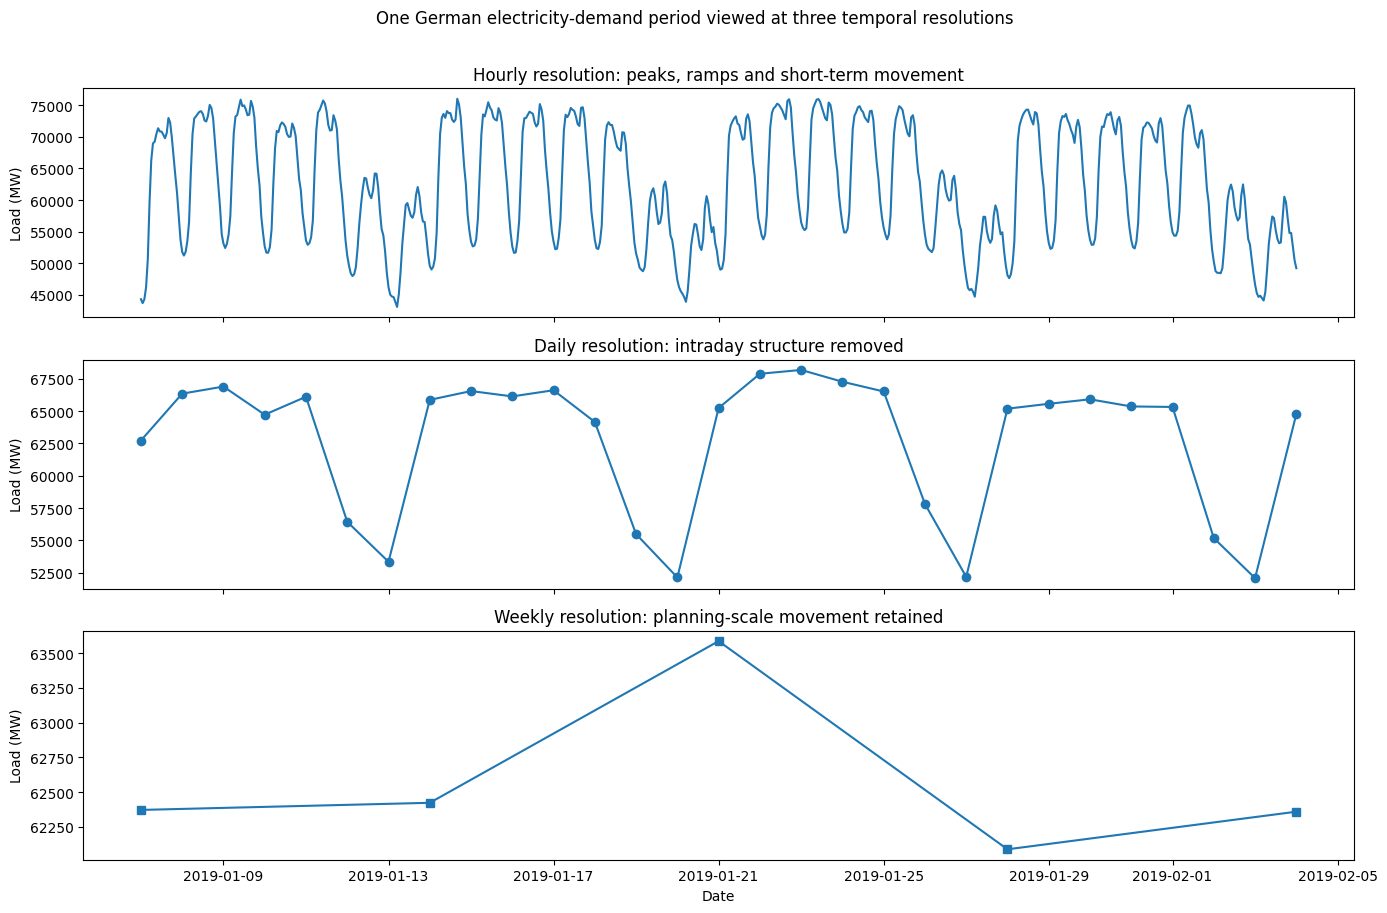

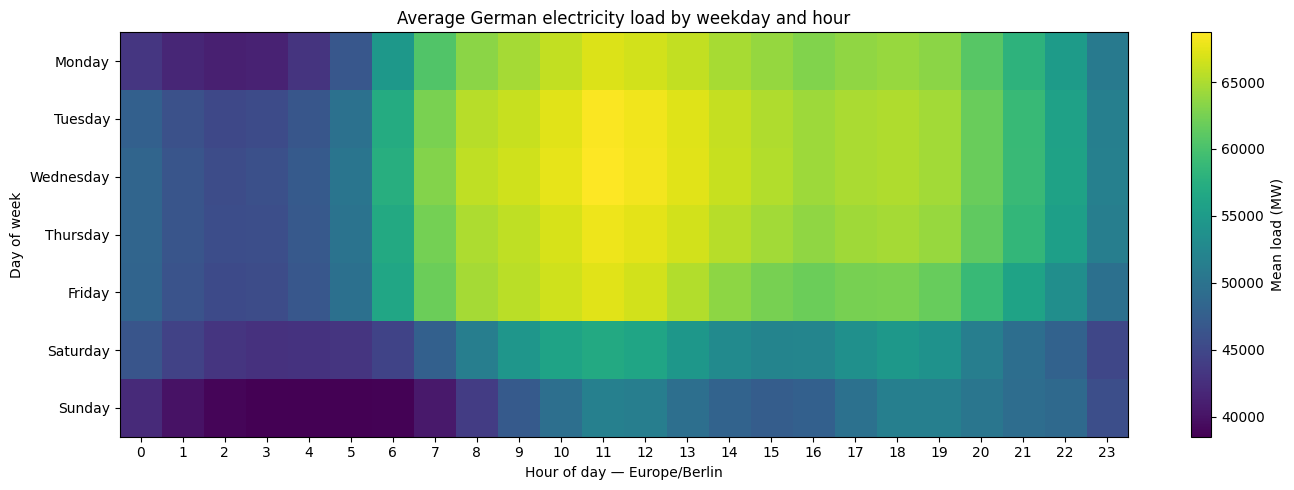

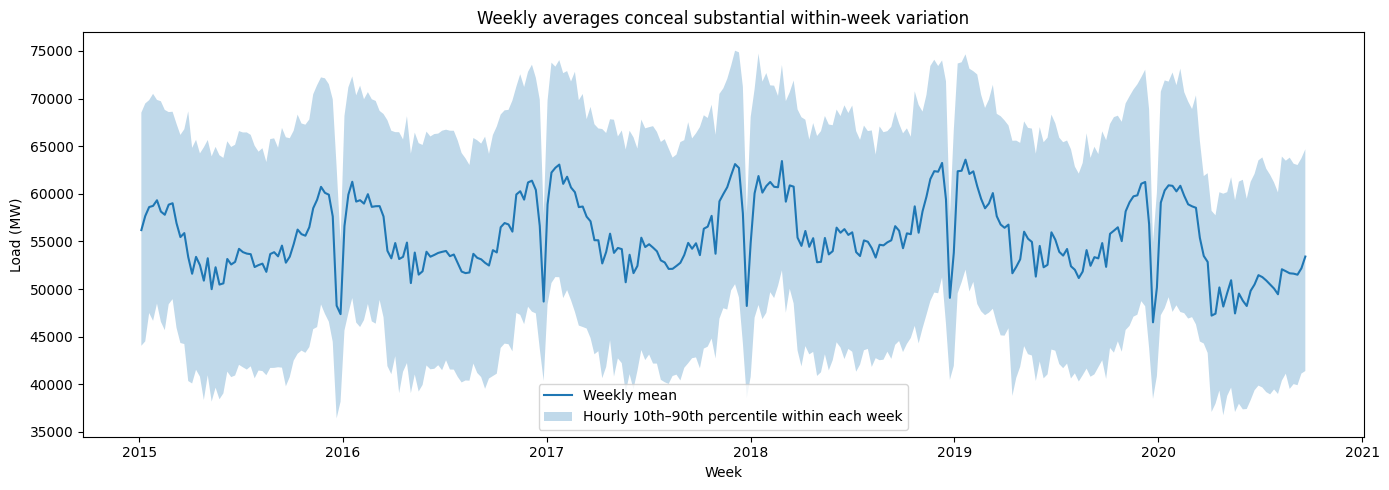

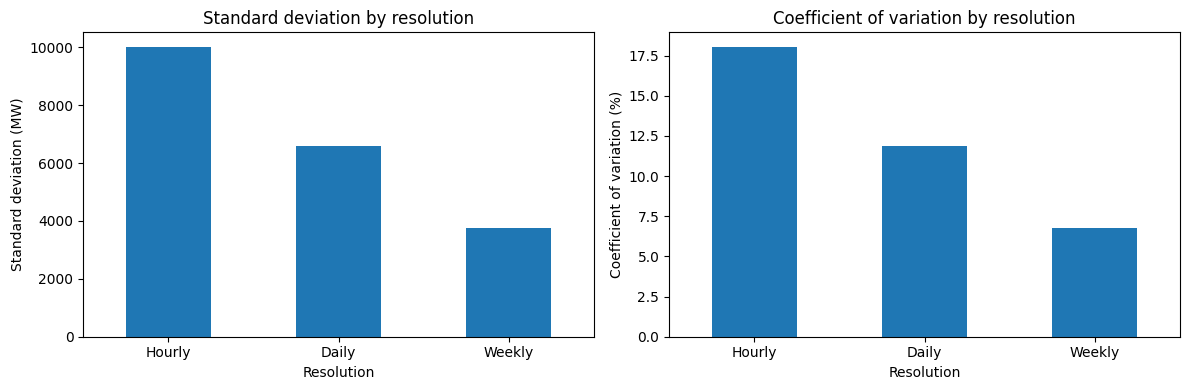

In [3]:
# ============================================================
# CELL 3: MULTI-RESOLUTION EXPLORATORY DATA ANALYSIS
# ============================================================
# The purpose of this EDA is to investigate what information
# is retained or lost when hourly load is aggregated to daily
# and weekly resolution.
#
# The plots are designed around the research question rather
# than using unrelated standard charts.
# ============================================================

def describe_resolution(series, label):
    """Return comparable descriptive measures."""

    return {
        "Resolution": label,
        "Observations": len(series),
        "Mean_MW": series.mean(),
        "Std_MW": series.std(),
        "CV_percent": (
            100 * series.std() / series.mean()
        ),
        "IQR_MW": (
            series.quantile(0.75)
            - series.quantile(0.25)
        ),
        "Minimum_MW": series.min(),
        "Maximum_MW": series.max(),
        "Lag1_autocorrelation": series.autocorr(lag=1)
    }


resolution_table = pd.DataFrame([
    describe_resolution(hourly, "Hourly"),
    describe_resolution(daily, "Daily"),
    describe_resolution(weekly, "Weekly")
]).set_index("Resolution")

display(resolution_table.round(3))

resolution_table.to_csv(
    TABLE_DIR / "resolution_statistics.csv"
)


# ---------------------------------------------------------
# FIGURE 1: Same four-week period at three resolutions
# ---------------------------------------------------------

representative_start = pd.Timestamp(
    "2019-01-07",
    tz="UTC"
)

representative_end = (
    representative_start
    + pd.Timedelta(weeks=4)
)

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 9),
    sharex=True
)

axes[0].plot(
    hourly.loc[
        representative_start:representative_end
    ]
)

axes[0].set_title(
    "Hourly resolution: peaks, ramps and short-term movement"
)

axes[1].plot(
    daily.loc[
        representative_start:representative_end
    ],
    marker="o"
)

axes[1].set_title(
    "Daily resolution: intraday structure removed"
)

axes[2].plot(
    weekly.loc[
        representative_start:representative_end
    ],
    marker="s"
)

axes[2].set_title(
    "Weekly resolution: planning-scale movement retained"
)

for axis in axes:
    axis.set_ylabel("Load (MW)")

axes[2].set_xlabel("Date")

fig.suptitle(
    "One German electricity-demand period viewed "
    "at three temporal resolutions",
    y=1.01
)

save_plot(
    "01_same_period_three_resolutions.png"
)


# ---------------------------------------------------------
# FIGURE 2: Weekday-hour demand fingerprint
# ---------------------------------------------------------

heatmap_data = pd.DataFrame({
    "load_mw": hourly_local.to_numpy(),
    "weekday": hourly_local.index.day_name(),
    "hour": hourly_local.index.hour
})

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

hour_week_matrix = (
    heatmap_data
    .pivot_table(
        index="weekday",
        columns="hour",
        values="load_mw",
        aggfunc="mean"
    )
    .reindex(weekday_order)
)

fig, ax = plt.subplots(figsize=(14, 5))

image = ax.imshow(
    hour_week_matrix,
    aspect="auto",
    cmap="viridis"
)

ax.set_xticks(range(24))
ax.set_xticklabels(range(24))

ax.set_yticks(range(7))
ax.set_yticklabels(weekday_order)

ax.set_xlabel("Hour of day — Europe/Berlin")
ax.set_ylabel("Day of week")

ax.set_title(
    "Average German electricity load by weekday and hour"
)

fig.colorbar(
    image,
    ax=ax,
    label="Mean load (MW)"
)

save_plot(
    "02_weekday_hour_heatmap.png"
)


# ---------------------------------------------------------
# FIGURE 3: Information hidden by weekly aggregation
# ---------------------------------------------------------

weekly_distribution = hourly.resample(
    WEEK_FREQ,
    label="left",
    closed="left"
).agg(
    mean_mw="mean",
    q10_mw=lambda x: x.quantile(0.10),
    q90_mw=lambda x: x.quantile(0.90),
    minimum_mw="min",
    maximum_mw="max",
    count="count"
)

weekly_distribution = weekly_distribution[
    weekly_distribution["count"] == 168
]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    weekly_distribution.index,
    weekly_distribution["mean_mw"],
    label="Weekly mean"
)

ax.fill_between(
    weekly_distribution.index,
    weekly_distribution["q10_mw"],
    weekly_distribution["q90_mw"],
    alpha=0.28,
    label=(
        "Hourly 10th–90th percentile "
        "within each week"
    )
)

ax.set_title(
    "Weekly averages conceal substantial "
    "within-week variation"
)

ax.set_xlabel("Week")
ax.set_ylabel("Load (MW)")
ax.legend()

save_plot(
    "03_information_lost_by_aggregation.png"
)


# ---------------------------------------------------------
# FIGURE 4: Variability reduction after aggregation
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

resolution_table["Std_MW"].plot(
    kind="bar",
    ax=axes[0],
    title="Standard deviation by resolution"
)

resolution_table["CV_percent"].plot(
    kind="bar",
    ax=axes[1],
    title="Coefficient of variation by resolution"
)

axes[0].set_ylabel("Standard deviation (MW)")
axes[1].set_ylabel("Coefficient of variation (%)")

for axis in axes:
    axis.tick_params(
        axis="x",
        rotation=0
    )

save_plot(
    "04_variability_reduction.png"
)

,Series,Observations,ADF_statistic,ADF_pvalue,ADF_lags,KPSS_statistic,KPSS_pvalue
0,Hourly original,50400,-42.2042,0.0000,24,1.0757,0.0100
1,Daily original,2100,-5.7571,0.0000,14,0.5395,0.0328
2,Weekly original,299,-3.9005,0.0020,8,0.1632,0.1000
3,Weekly first difference,298,-7.0351,0.0000,7,0.0313,0.1000
4,Weekly seasonal difference at lag 52,247,-1.8042,0.3784,11,1.4238,0.0100
5,Weekly first plus seasonal difference,246,-7.6900,0.0000,10,0.0346,0.1000


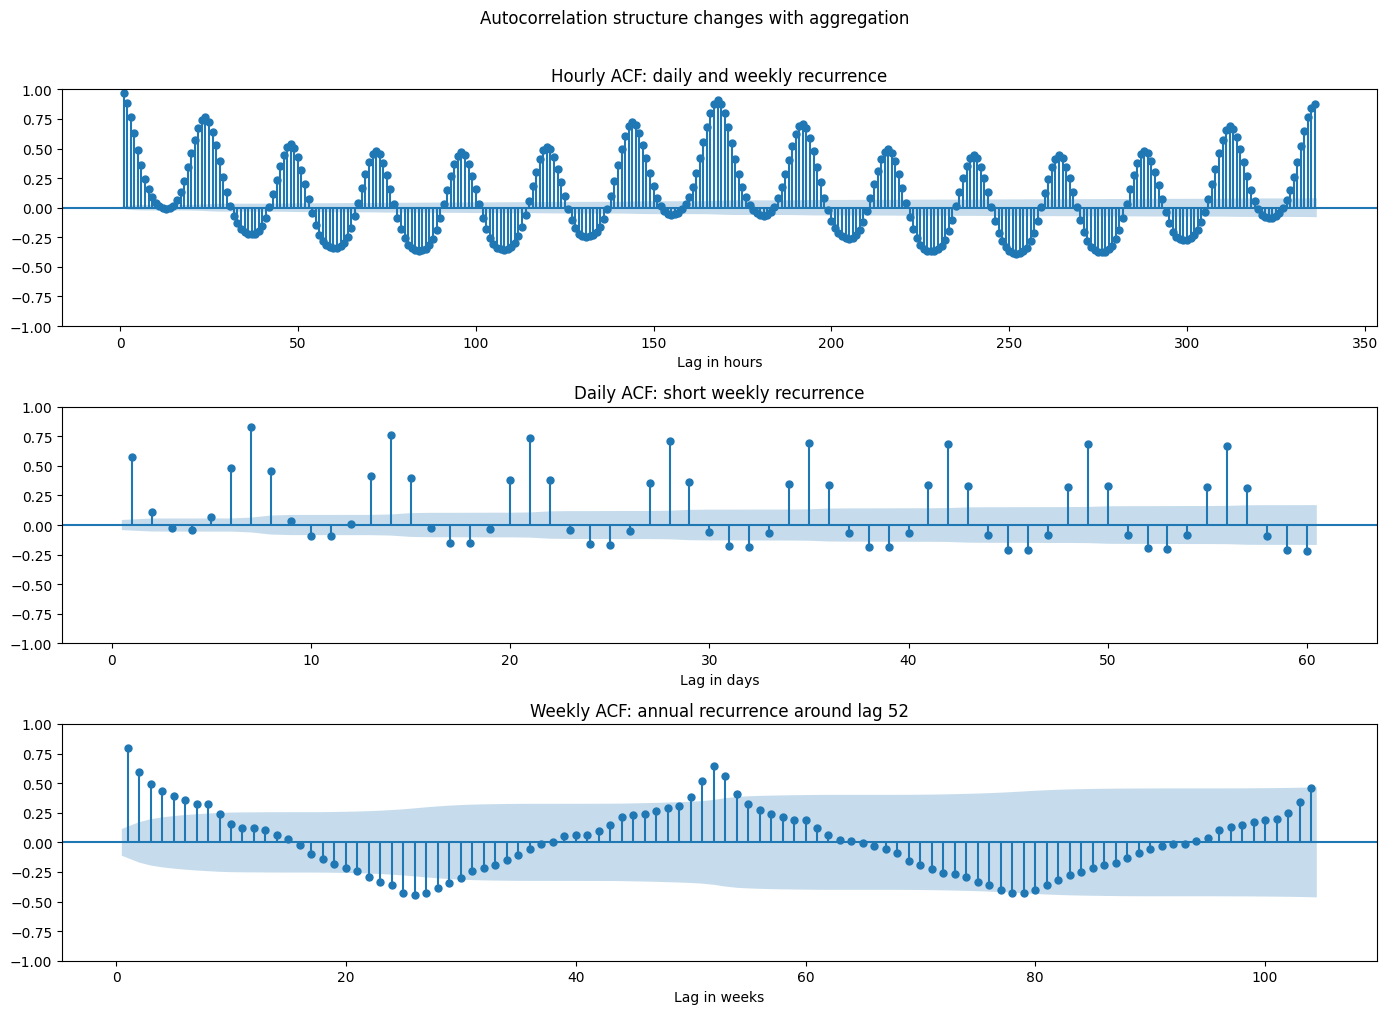

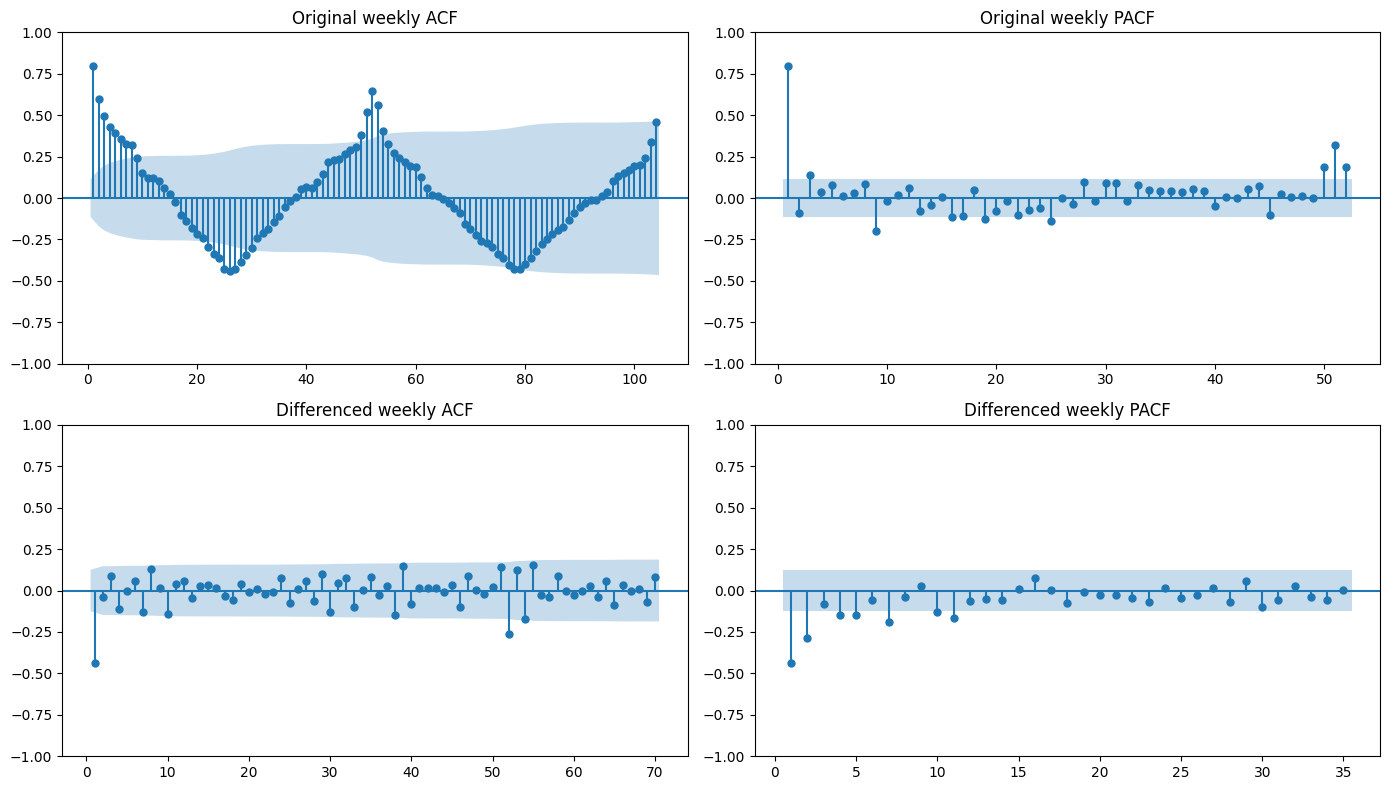

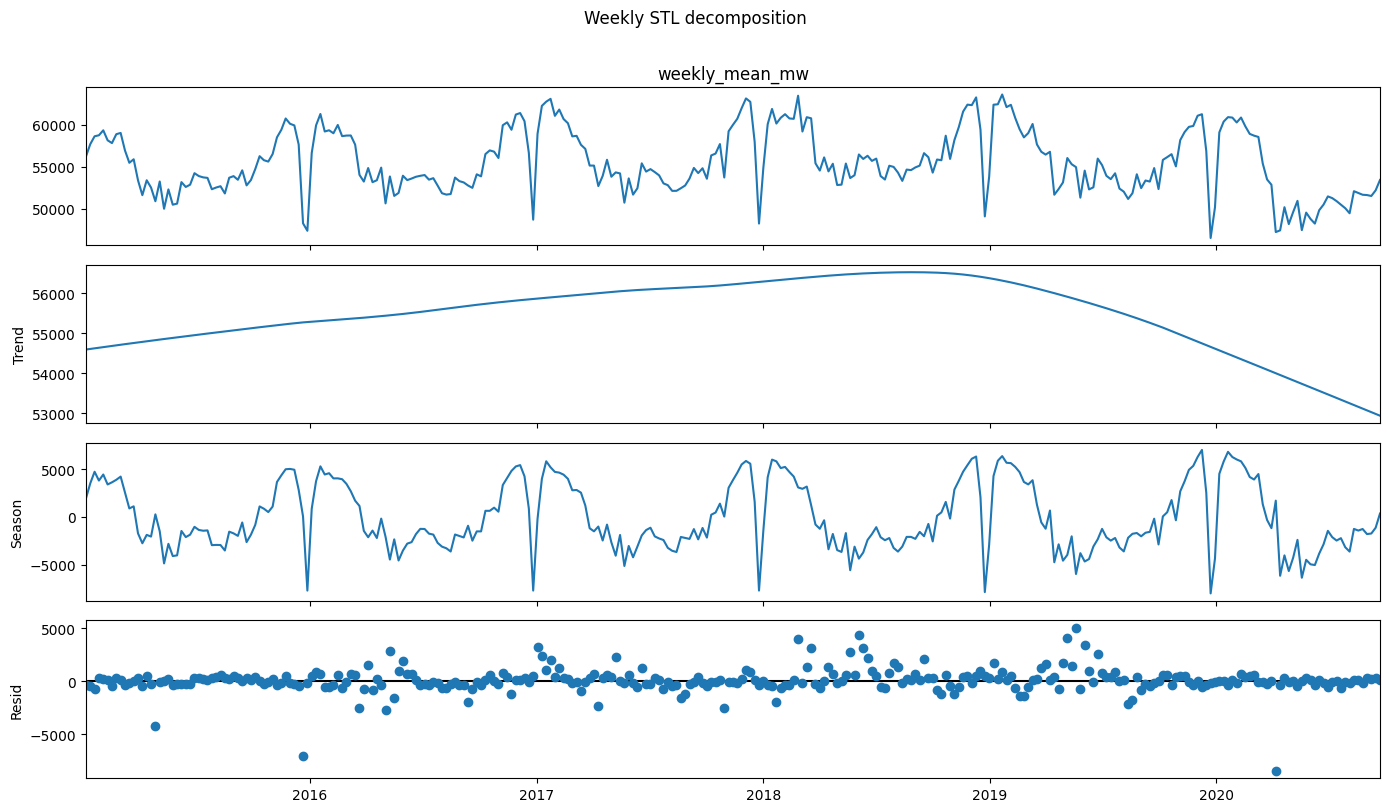

In [4]:
# ============================================================
# CELL 4: STATIONARITY AND SEASONAL-STRUCTURE ANALYSIS
# ============================================================
# This cell:
# 1. Applies ADF and KPSS tests.
# 2. Compares stationarity at hourly, daily and weekly levels.
# 3. Tests first and seasonal differencing for weekly data.
# 4. Compares autocorrelation across resolutions.
# 5. Uses STL decomposition to separate weekly trend,
#    annual seasonality and residual behaviour.
# ============================================================

def stationarity_test(series, label, maximum_lag):
    """Run complementary ADF and KPSS tests."""

    clean_series = (
        pd.Series(series)
        .dropna()
        .astype(float)
    )

    adf_result = adfuller(
        clean_series,
        maxlag=maximum_lag,
        autolag="AIC",
        regression="c"
    )

    try:
        kpss_result = kpss(
            clean_series,
            regression="c",
            nlags="auto"
        )

        kpss_statistic = kpss_result[0]
        kpss_pvalue = kpss_result[1]

    except Exception:
        kpss_statistic = np.nan
        kpss_pvalue = np.nan

    return {
        "Series": label,
        "Observations": len(clean_series),
        "ADF_statistic": adf_result[0],
        "ADF_pvalue": adf_result[1],
        "ADF_lags": adf_result[2],
        "KPSS_statistic": kpss_statistic,
        "KPSS_pvalue": kpss_pvalue
    }


weekly_first_difference = weekly.diff()

weekly_seasonal_difference = weekly.diff(
    SEASON_LENGTH
)

weekly_combined_difference = (
    weekly
    .diff()
    .diff(SEASON_LENGTH)
)

stationarity_results = pd.DataFrame([
    stationarity_test(
        hourly,
        "Hourly original",
        24
    ),
    stationarity_test(
        daily,
        "Daily original",
        14
    ),
    stationarity_test(
        weekly,
        "Weekly original",
        20
    ),
    stationarity_test(
        weekly_first_difference,
        "Weekly first difference",
        20
    ),
    stationarity_test(
        weekly_seasonal_difference,
        "Weekly seasonal difference at lag 52",
        20
    ),
    stationarity_test(
        weekly_combined_difference,
        "Weekly first plus seasonal difference",
        20
    )
])

display(stationarity_results.round(4))

stationarity_results.to_csv(
    TABLE_DIR / "stationarity_results.csv",
    index=False
)


# ---------------------------------------------------------
# FIGURE 5: ACF comparison at appropriate resolutions
# ---------------------------------------------------------

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 10)
)

plot_acf(
    hourly,
    lags=336,
    fft=True,
    zero=False,
    ax=axes[0]
)

axes[0].set_title(
    "Hourly ACF: daily and weekly recurrence"
)

axes[0].set_xlabel("Lag in hours")

plot_acf(
    daily,
    lags=60,
    fft=True,
    zero=False,
    ax=axes[1]
)

axes[1].set_title(
    "Daily ACF: short weekly recurrence"
)

axes[1].set_xlabel("Lag in days")

plot_acf(
    weekly,
    lags=104,
    fft=True,
    zero=False,
    ax=axes[2]
)

axes[2].set_title(
    "Weekly ACF: annual recurrence around lag 52"
)

axes[2].set_xlabel("Lag in weeks")

fig.suptitle(
    "Autocorrelation structure changes with aggregation",
    y=1.01
)

save_plot(
    "05_acf_across_resolutions.png"
)


# ---------------------------------------------------------
# FIGURE 6: Weekly ACF and PACF before/after differencing
# ---------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 8)
)

plot_acf(
    weekly,
    lags=104,
    fft=True,
    zero=False,
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Original weekly ACF"
)

plot_pacf(
    weekly,
    lags=52,
    method="ywm",
    zero=False,
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Original weekly PACF"
)

plot_acf(
    weekly_combined_difference.dropna(),
    lags=70,
    fft=True,
    zero=False,
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "Differenced weekly ACF"
)

plot_pacf(
    weekly_combined_difference.dropna(),
    lags=35,
    method="ywm",
    zero=False,
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Differenced weekly PACF"
)

save_plot(
    "06_weekly_acf_pacf.png"
)


# ---------------------------------------------------------
# FIGURE 7: Robust annual weekly decomposition
# ---------------------------------------------------------

stl_result = STL(
    weekly,
    period=SEASON_LENGTH,
    robust=True
).fit()

figure = stl_result.plot()

figure.set_size_inches(
    14,
    8
)

figure.suptitle(
    "Weekly STL decomposition",
    y=1.01
)

save_plot(
    "07_weekly_stl.png"
)

Training period: 2015-01-05 00:00:00+00:00 to 2018-09-24 00:00:00+00:00
Test period: 2018-10-01 00:00:00+00:00 to 2020-09-21 00:00:00+00:00


,MAE,RMSE,sMAPE_percent,MASE
Seasonal Naive,2288.489,2988.248,4.207,1.694
Mean,3789.845,4402.059,6.874,2.805
Drift,3850.776,4466.494,6.982,2.850
Naive,3858.148,4475.767,6.995,2.856


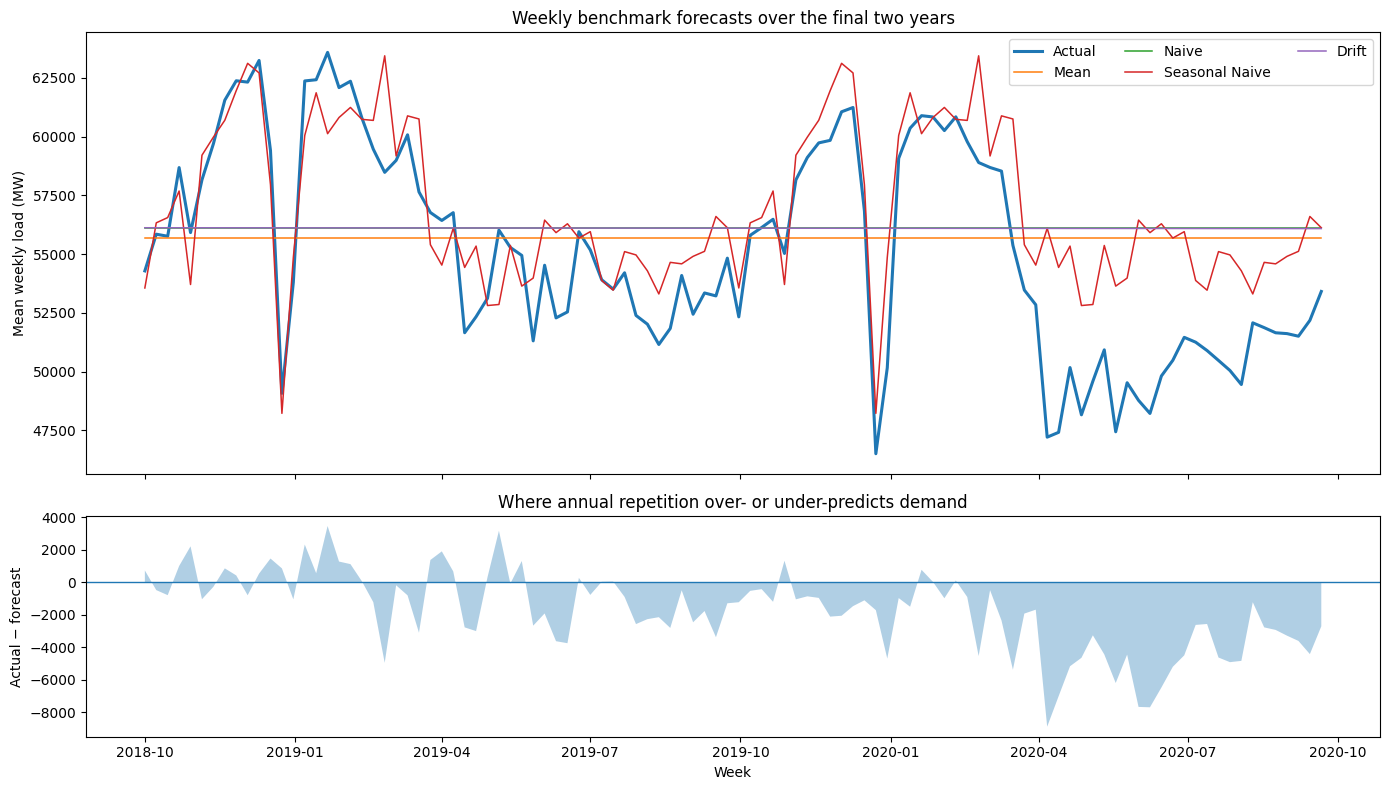

In [5]:
# ============================================================
# CELL 5: CREATE THE TWO-YEAR TEST SET AND BENCHMARK MODELS
# ============================================================
# The final 104 complete weeks are used as the common test set.
#
# Four lecture benchmark models are included:
# 1. Mean forecast
# 2. Naive forecast
# 3. Seasonal Naive forecast
# 4. Drift forecast
#
# Every later weekly model will be evaluated on exactly the
# same dates using the same metrics.
# ============================================================

y_train = weekly.iloc[:-TEST_WEEKS].copy()
y_test = weekly.iloc[-TEST_WEEKS:].copy()

if len(y_train) < 2 * SEASON_LENGTH:
    raise ValueError(
        "Insufficient weekly training history."
    )


def smape(actual, predicted):
    """Symmetric mean absolute percentage error."""

    actual = np.asarray(
        actual,
        dtype=float
    )

    predicted = np.asarray(
        predicted,
        dtype=float
    )

    denominator = (
        np.abs(actual)
        + np.abs(predicted)
    )

    individual_errors = np.where(
        denominator == 0,
        0,
        (
            2
            * np.abs(predicted - actual)
            / denominator
        )
    )

    return 100 * np.mean(individual_errors)


def mase(
    actual,
    predicted,
    training_series,
    season_length=52
):
    """Mean absolute scaled error."""

    training_values = np.asarray(
        training_series,
        dtype=float
    )

    scale = np.mean(
        np.abs(
            training_values[season_length:]
            - training_values[:-season_length]
        )
    )

    return (
        np.mean(
            np.abs(
                np.asarray(actual)
                - np.asarray(predicted)
            )
        )
        / scale
    )


def evaluate_forecast(
    actual,
    predicted,
    training_series
):
    """Calculate common weekly evaluation metrics."""

    predicted = pd.Series(
        np.asarray(predicted, dtype=float),
        index=actual.index
    )

    return {
        "MAE": mean_absolute_error(
            actual,
            predicted
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                actual,
                predicted
            )
        ),
        "sMAPE_percent": smape(
            actual,
            predicted
        ),
        "MASE": mase(
            actual,
            predicted,
            training_series
        )
    }


def mean_forecast(train, forecast_index):
    return pd.Series(
        train.mean(),
        index=forecast_index
    )


def naive_forecast(train, forecast_index):
    return pd.Series(
        train.iloc[-1],
        index=forecast_index
    )


def seasonal_naive_forecast(
    train,
    forecast_index,
    season_length=52
):
    seasonal_pattern = (
        train
        .iloc[-season_length:]
        .to_numpy()
    )

    repeated_pattern = np.resize(
        seasonal_pattern,
        len(forecast_index)
    )

    return pd.Series(
        repeated_pattern,
        index=forecast_index
    )


def drift_forecast(train, forecast_index):
    slope = (
        train.iloc[-1]
        - train.iloc[0]
    ) / (
        len(train) - 1
    )

    forecast_steps = np.arange(
        1,
        len(forecast_index) + 1
    )

    forecast_values = (
        train.iloc[-1]
        + slope * forecast_steps
    )

    return pd.Series(
        forecast_values,
        index=forecast_index
    )


predictions = {
    "Mean": mean_forecast(
        y_train,
        y_test.index
    ),
    "Naive": naive_forecast(
        y_train,
        y_test.index
    ),
    "Seasonal Naive": seasonal_naive_forecast(
        y_train,
        y_test.index
    ),
    "Drift": drift_forecast(
        y_train,
        y_test.index
    )
}

benchmark_metrics = pd.DataFrame({
    model_name: evaluate_forecast(
        y_test,
        model_prediction,
        y_train
    )
    for model_name, model_prediction
    in predictions.items()
}).T

benchmark_metrics = benchmark_metrics.sort_values(
    "RMSE"
)

print(
    "Training period:",
    y_train.index.min(),
    "to",
    y_train.index.max()
)

print(
    "Test period:",
    y_test.index.min(),
    "to",
    y_test.index.max()
)

display(
    benchmark_metrics.round(3)
)

benchmark_metrics.to_csv(
    TABLE_DIR / "benchmark_metrics.csv"
)


# Benchmark forecasts plus signed seasonal-naive error.
fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 8),
    sharex=True,
    gridspec_kw={
        "height_ratios": [2, 1]
    }
)

axes[0].plot(
    y_test,
    linewidth=2.2,
    label="Actual"
)

for model_name, prediction in predictions.items():
    axes[0].plot(
        prediction,
        linewidth=1.1,
        label=model_name
    )

axes[0].set_title(
    "Weekly benchmark forecasts over the final two years"
)

axes[0].set_ylabel(
    "Mean weekly load (MW)"
)

axes[0].legend(
    ncol=3
)

seasonal_naive_error = (
    y_test
    - predictions["Seasonal Naive"]
)

axes[1].axhline(
    0,
    linewidth=1
)

axes[1].fill_between(
    seasonal_naive_error.index,
    0,
    seasonal_naive_error,
    alpha=0.35
)

axes[1].set_title(
    "Where annual repetition over- or under-predicts demand"
)

axes[1].set_xlabel("Week")

axes[1].set_ylabel(
    "Actual − forecast"
)

save_plot(
    "08_benchmark_forecasts.png"
)

,temp_mean,temp_min,temp_max,HDD18,CDD22,holiday_days,working_days,christmas_new_year,week_sin,week_cos,trend
timestamp,,,,,,,,,,,
2015-01-05 00:00:00+00:00,3.902381,-0.5,11.6,98.683333,0.0,0,5,1,0.239316,0.970942,1
2015-01-12 00:00:00+00:00,4.837500,-2.9,11.2,92.137500,0.0,0,5,0,0.354605,0.935016,2
2015-01-19 00:00:00+00:00,0.057143,-3.6,3.4,125.600000,0.0,0,5,0,0.464723,0.885456,3
2015-01-26 00:00:00+00:00,1.373214,-1.2,4.7,116.387500,0.0,0,5,0,0.568065,0.822984,4
2015-02-02 00:00:00+00:00,-1.243452,-8.2,2.9,134.704167,0.0,0,5,0,0.663123,0.748511,5


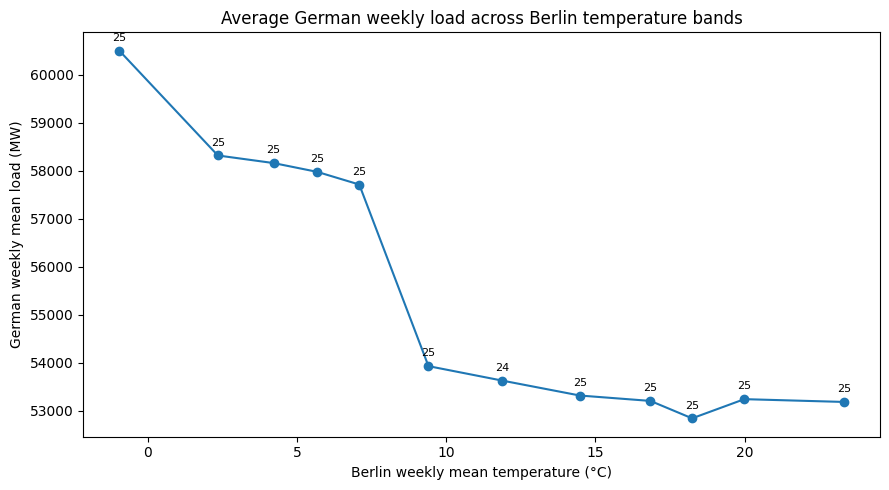

In [6]:
# ============================================================
# CELL 6: DOWNLOAD BERLIN TEMPERATURE AND CREATE COVARIATES
# ============================================================
# Berlin is used as the representative location requested
# by the assignment.
#
# The following weekly variables are prepared:
# - Mean, minimum and maximum temperature
# - Heating degree days
# - Cooling degree days
# - Number of holidays
# - Number of working days
# - Christmas/New Year indicator
# - Cyclical week-of-year variables
# - Long-term trend
#
# Observed temperature from the test period creates a
# conditional forecast, not a fully operational forecast.
# ============================================================

weather_url = (
    "https://archive-api.open-meteo.com/v1/archive"
)

weather_parameters = {
    "latitude": 52.5200,
    "longitude": 13.4050,
    "start_date": (
        hourly.index.min()
        .date()
        .isoformat()
    ),
    "end_date": (
        hourly.index.max()
        .date()
        .isoformat()
    ),
    "hourly": "temperature_2m",
    "temperature_unit": "celsius",
    "timezone": "UTC"
}

weather_response = requests.get(
    weather_url,
    params=weather_parameters,
    timeout=120
)

weather_response.raise_for_status()

weather_json = weather_response.json()

temperature_hourly = pd.Series(
    weather_json["hourly"]["temperature_2m"],
    index=pd.to_datetime(
        weather_json["hourly"]["time"],
        utc=True
    ),
    name="temperature_c",
    dtype=float
)

temperature_hourly = (
    temperature_hourly
    .reindex(hourly.index)
    .interpolate(
        method="time",
        limit=6,
        limit_direction="both"
    )
)

if temperature_hourly.isna().any():
    raise ValueError(
        "Temperature data contain unresolved gaps."
    )

temperature_daily = (
    temperature_hourly
    .resample("D")
    .mean()
)

weather_weekly = (
    temperature_hourly
    .resample(
        WEEK_FREQ,
        label="left",
        closed="left"
    )
    .agg([
        "mean",
        "min",
        "max"
    ])
)

weather_weekly.columns = [
    "temp_mean",
    "temp_min",
    "temp_max"
]

# Heating degree days.
weather_weekly["HDD18"] = (
    (18 - temperature_daily)
    .clip(lower=0)
    .resample(
        WEEK_FREQ,
        label="left",
        closed="left"
    )
    .sum()
)

# Cooling degree days.
weather_weekly["CDD22"] = (
    (temperature_daily - 22)
    .clip(lower=0)
    .resample(
        WEEK_FREQ,
        label="left",
        closed="left"
    )
    .sum()
)


# ---------------------------------------------------------
# German calendar variables
# ---------------------------------------------------------

available_years = range(
    hourly.index.min().year,
    hourly.index.max().year + 1
)

german_holidays = holidays.Germany(
    years=available_years
)

calendar_dates = pd.date_range(
    start=hourly.index.min().normalize(),
    end=hourly.index.max().normalize(),
    freq="D",
    tz="UTC"
)

daily_calendar = pd.DataFrame(
    index=calendar_dates
)

daily_calendar["is_holiday"] = [
    int(date.date() in german_holidays)
    for date in calendar_dates
]

daily_calendar["is_weekday"] = (
    daily_calendar.index.weekday < 5
).astype(int)

daily_calendar["working_day"] = (
    (
        daily_calendar["is_weekday"] == 1
    )
    &
    (
        daily_calendar["is_holiday"] == 0
    )
).astype(int)

daily_calendar["christmas_new_year"] = (
    (
        (
            daily_calendar.index.month == 12
        )
        &
        (
            daily_calendar.index.day >= 20
        )
    )
    |
    (
        (
            daily_calendar.index.month == 1
        )
        &
        (
            daily_calendar.index.day <= 7
        )
    )
).astype(int)

calendar_weekly = daily_calendar.resample(
    WEEK_FREQ,
    label="left",
    closed="left"
).agg(
    holiday_days=(
        "is_holiday",
        "sum"
    ),
    working_days=(
        "working_day",
        "sum"
    ),
    christmas_new_year=(
        "christmas_new_year",
        "max"
    )
)

iso_week = (
    calendar_weekly
    .index
    .isocalendar()
    .week
    .astype(int)
)

calendar_weekly["week_sin"] = np.sin(
    2 * np.pi * iso_week / 52
)

calendar_weekly["week_cos"] = np.cos(
    2 * np.pi * iso_week / 52
)

calendar_weekly["trend"] = np.arange(
    len(calendar_weekly)
)

exogenous_weekly = (
    weather_weekly
    .join(
        calendar_weekly,
        how="inner"
    )
    .reindex(weekly.index)
)

if exogenous_weekly.isna().any().any():
    raise ValueError(
        "Weekly load and exogenous variables "
        "are not correctly aligned."
    )

display(
    exogenous_weekly.head()
)


# ---------------------------------------------------------
# Unique nonlinear temperature-response plot
# ---------------------------------------------------------

temperature_relationship = pd.DataFrame({
    "load_mw": weekly,
    "temperature_c": (
        exogenous_weekly["temp_mean"]
    )
}).dropna()

temperature_relationship[
    "temperature_band"
] = pd.qcut(
    temperature_relationship[
        "temperature_c"
    ],
    q=12,
    duplicates="drop"
)

temperature_curve = (
    temperature_relationship
    .groupby(
        "temperature_band",
        observed=True
    )
    .agg(
        temperature_c=(
            "temperature_c",
            "mean"
        ),
        load_mw=(
            "load_mw",
            "mean"
        ),
        number_of_weeks=(
            "load_mw",
            "size"
        )
    )
)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    temperature_curve[
        "temperature_c"
    ],
    temperature_curve[
        "load_mw"
    ],
    marker="o"
)

for _, row in temperature_curve.iterrows():
    ax.annotate(
        str(
            int(
                row["number_of_weeks"]
            )
        ),
        (
            row["temperature_c"],
            row["load_mw"]
        ),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

ax.set_title(
    "Average German weekly load across Berlin temperature bands"
)

ax.set_xlabel(
    "Berlin weekly mean temperature (°C)"
)

ax.set_ylabel(
    "German weekly mean load (MW)"
)

save_plot(
    "09_temperature_response.png"
)

In [7]:
# ============================================================
# CELL 7: EFFICIENT SARIMA AIC PARAMETER SEARCH
# ============================================================
# The assignment requires every combination of:
# p = 0, 1, 2, 3, 4, 5, 6
# d = 0, 1, 2
# q = 0, 1, 2, 3, 4, 5, 6
#
# This produces:
# 7 × 3 × 7 = 147 required non-seasonal combinations.
#
# To reduce unnecessary runtime:
# 1. All 147 combinations are screened using one compact
#    annual seasonal structure.
# 2. Only the strongest non-seasonal candidates are tested
#    across additional seasonal structures.
# 3. Search progress is saved so an interrupted Colab session
#    can resume instead of restarting.
# ============================================================

nonseasonal_orders = list(
    itertools.product(
        range(0, 7),
        range(0, 3),
        range(0, 7)
    )
)

# Use one evidence-supported seasonal structure
# during the initial screening stage.
screening_seasonal_order = (
    0,
    1,
    1,
    52
)

screening_cache_file = (
    CACHE_DIR
    / "sarima_screening.csv"
)


def fit_sarima_candidate(
    order,
    seasonal_order,
    maximum_iterations=20
):
    """Fit one SARIMA candidate and return diagnostics."""

    start_time = time.time()

    try:
        model = SARIMAX(
            y_train,
            order=order,
            seasonal_order=seasonal_order,
            trend="n",
            enforce_stationarity=False,
            enforce_invertibility=False,
            concentrate_scale=True,
            simple_differencing=True
        )

        result = model.fit(
            method="lbfgs",
            maxiter=maximum_iterations,
            disp=False
        )

        return {
            "order": str(order),
            "seasonal_order": str(
                seasonal_order
            ),
            "AIC": result.aic,
            "BIC": result.bic,
            "converged": bool(
                result.mle_retvals.get(
                    "converged",
                    False
                )
            ),
            "seconds": (
                time.time()
                - start_time
            ),
            "error": ""
        }

    except Exception as error:
        return {
            "order": str(order),
            "seasonal_order": str(
                seasonal_order
            ),
            "AIC": np.inf,
            "BIC": np.inf,
            "converged": False,
            "seconds": (
                time.time()
                - start_time
            ),
            "error": str(error)[:180]
        }


# Resume the search when a previous cache exists.
if screening_cache_file.exists():

    screening_results = pd.read_csv(
        screening_cache_file
    )

    completed_orders = set(
        screening_results["order"]
    )

else:

    screening_results = pd.DataFrame()

    completed_orders = set()


screening_rows = (
    screening_results
    .to_dict("records")
)

for number, order in enumerate(
    nonseasonal_orders,
    start=1
):

    if str(order) in completed_orders:
        continue

    result_row = fit_sarima_candidate(
        order=order,
        seasonal_order=(
            screening_seasonal_order
        ),
        maximum_iterations=20
    )

    screening_rows.append(
        result_row
    )

    if number % 10 == 0:

        pd.DataFrame(
            screening_rows
        ).to_csv(
            screening_cache_file,
            index=False
        )

        print(
            f"Screened "
            f"{len(screening_rows)}/147 "
            f"orders"
        )


screening_results = pd.DataFrame(
    screening_rows
)

screening_results.to_csv(
    screening_cache_file,
    index=False
)

valid_screening_results = (
    screening_results[
        np.isfinite(
            screening_results["AIC"]
        )
    ]
    .sort_values("AIC")
)

print(
    "Required combinations attempted:",
    screening_results[
        "order"
    ].nunique()
)

display(
    valid_screening_results.head(10)
)


# ---------------------------------------------------------
# Refine the strongest non-seasonal orders
# ---------------------------------------------------------

top_nonseasonal_orders = [
    ast.literal_eval(order)
    for order
    in valid_screening_results
    .head(5)["order"]
]

seasonal_order_grid = [
    (0, 0, 0, 52),
    (1, 0, 0, 52),
    (0, 1, 1, 52),
    (1, 1, 1, 52)
]

refined_rows = []

for order in top_nonseasonal_orders:

    for seasonal_order in seasonal_order_grid:

        refined_rows.append(
            fit_sarima_candidate(
                order=order,
                seasonal_order=seasonal_order,
                maximum_iterations=70
            )
        )


sarima_refined_search = pd.DataFrame(
    refined_rows
)

sarima_refined_search = (
    sarima_refined_search[
        np.isfinite(
            sarima_refined_search["AIC"]
        )
    ]
    .sort_values("AIC")
)

display(
    sarima_refined_search.head(12)
)

sarima_refined_search.to_csv(
    TABLE_DIR
    / "sarima_refined_search.csv",
    index=False
)

best_order = ast.literal_eval(
    sarima_refined_search
    .iloc[0]["order"]
)

best_seasonal_order = ast.literal_eval(
    sarima_refined_search
    .iloc[0]["seasonal_order"]
)

print(
    "Selected non-seasonal order:",
    best_order
)

print(
    "Selected seasonal order:",
    best_seasonal_order
)

Screened 10/147 orders
Screened 20/147 orders
Screened 30/147 orders
Screened 40/147 orders
Screened 50/147 orders
Screened 60/147 orders
Screened 70/147 orders
Screened 80/147 orders
Screened 90/147 orders
Screened 100/147 orders
Screened 110/147 orders
Screened 120/147 orders
Screened 130/147 orders
Screened 140/147 orders
Required combinations attempted: 147


,order,seasonal_order,AIC,BIC,converged,seconds,error
62,"(2, 2, 6)","(0, 1, 1, 52)",1449.332327,1473.399519,False,3.757506,
41,"(1, 2, 6)","(0, 1, 1, 52)",1452.734705,1474.395178,False,3.812786,
20,"(0, 2, 6)","(0, 1, 1, 52)",1453.585430,1472.839184,False,6.079401,
83,"(3, 2, 6)","(0, 1, 1, 52)",1454.125000,1480.598912,False,4.355862,
104,"(4, 2, 6)","(0, 1, 1, 52)",1454.840778,1483.721408,False,5.872153,
125,"(5, 2, 6)","(0, 1, 1, 52)",1457.485121,1488.772472,False,7.113576,
13,"(0, 1, 6)","(0, 1, 1, 52)",1460.131877,1479.482602,True,2.938274,
34,"(1, 1, 6)","(0, 1, 1, 52)",1461.306515,1483.076081,False,4.365245,
76,"(3, 1, 6)","(0, 1, 1, 52)",1462.937461,1489.544708,False,4.532660,
55,"(2, 1, 6)","(0, 1, 1, 52)",1463.226872,1487.415278,False,6.129782,


,order,seasonal_order,AIC,BIC,converged,seconds,error
3,"(2, 2, 6)","(1, 1, 1, 52)",1444.158941,1470.632853,True,12.371078,
15,"(3, 2, 6)","(1, 1, 1, 52)",1444.527195,1473.407826,False,18.025435,
7,"(1, 2, 6)","(1, 1, 1, 52)",1445.425058,1469.492250,True,7.889771,
19,"(4, 2, 6)","(1, 1, 1, 52)",1446.403786,1477.691136,False,15.861133,
11,"(0, 2, 6)","(1, 1, 1, 52)",1446.635061,1468.295534,True,11.851329,
2,"(2, 2, 6)","(0, 1, 1, 52)",1449.251473,1473.318666,True,8.533710,
14,"(3, 2, 6)","(0, 1, 1, 52)",1451.325798,1477.799709,False,16.297541,
6,"(1, 2, 6)","(0, 1, 1, 52)",1452.642211,1474.302684,True,12.366000,
10,"(0, 2, 6)","(0, 1, 1, 52)",1453.376992,1472.630746,True,12.091663,
18,"(4, 2, 6)","(0, 1, 1, 52)",1453.502558,1482.383189,False,15.873571,


Selected non-seasonal order: (2, 2, 6)
Selected seasonal order: (1, 1, 1, 52)


                                      SARIMAX Results                                       
Dep. Variable:                       weekly_mean_mw   No. Observations:                  195
Model:             SARIMAX(2, 2, 6)x(1, 1, [1], 52)   Log Likelihood                -712.649
Date:                              Sun, 12 Jul 2026   AIC                           1447.299
Time:                                      08:02:11   BIC                           1473.773
Sample:                                  01-05-2015   HQIC                          1457.928
                                       - 09-24-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0704      0.048    -22.112      0.000      -1.165      -0.976
ar.L2         -0.99

,lb_stat,lb_pvalue
12,6.162038,0.907694
26,8.359708,0.999588
52,41.029469,0.863391


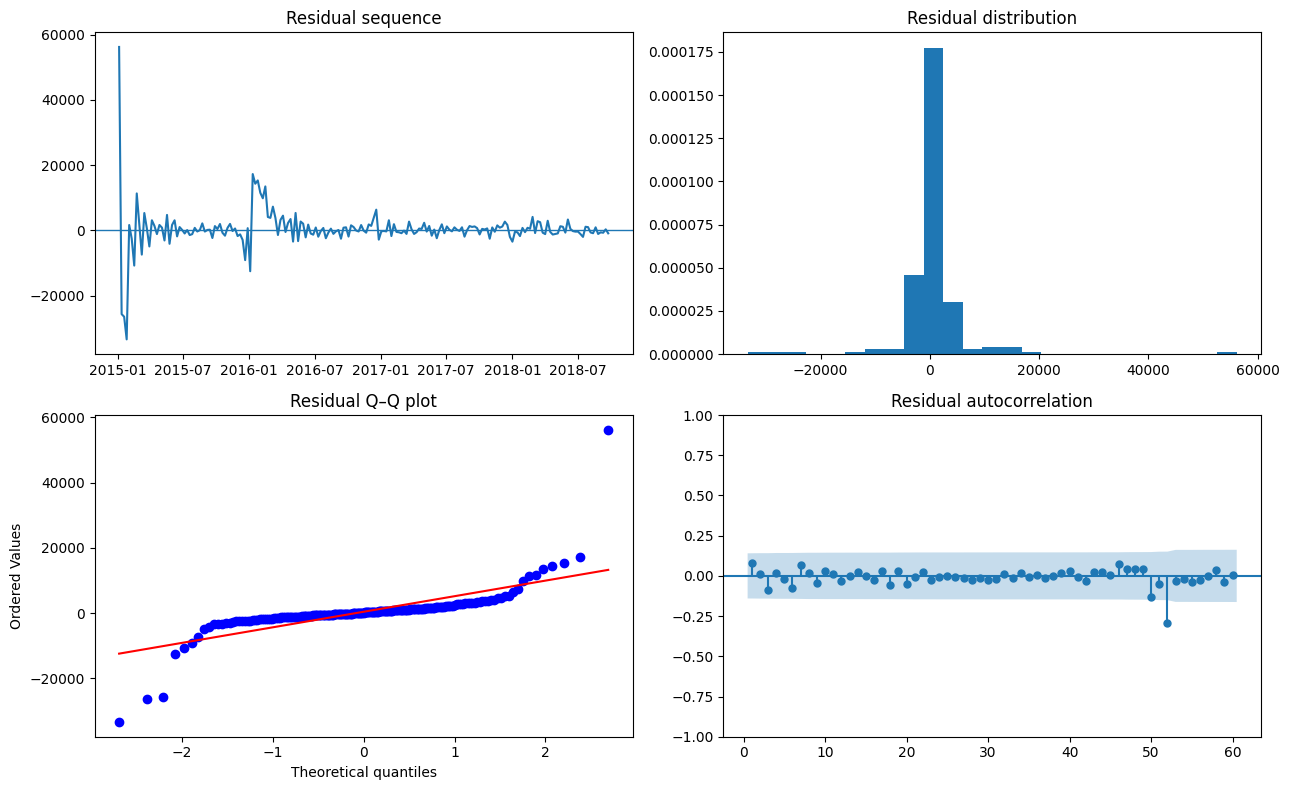

,MAE,RMSE,sMAPE_percent,MASE
SARIMA,7613.792,8872.824,13.012,5.635


Empirical coverage of the 95% interval: 0.923


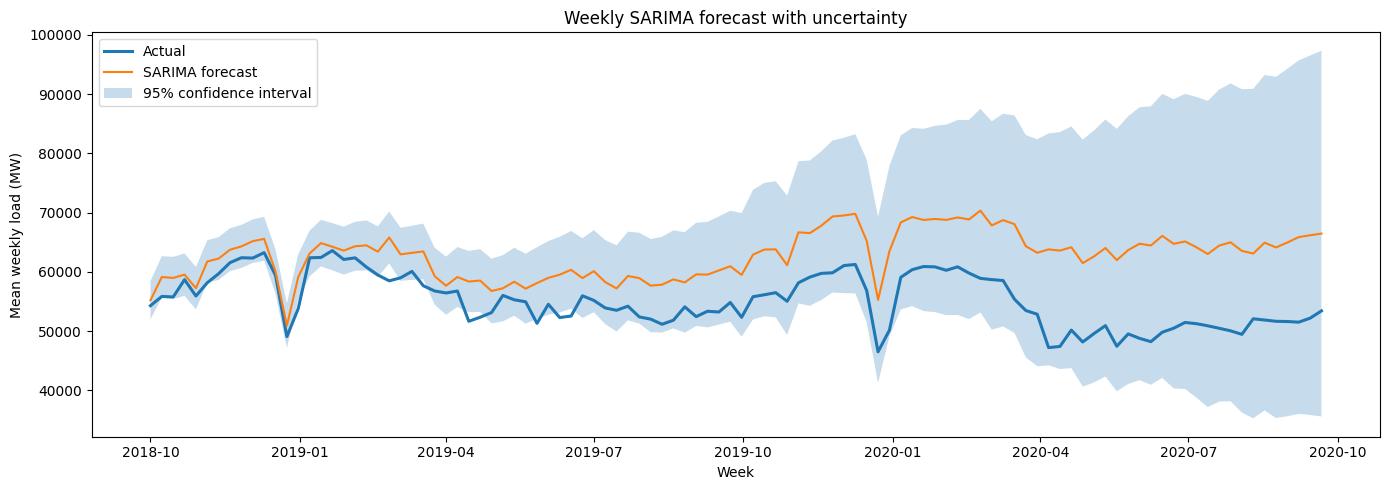

In [8]:
# CELL 8 — Final SARIMA, residual diagnostics and forecast

sarima_model = SARIMAX(
    y_train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(
    method="lbfgs",
    maxiter=180,
    disp=False
)

print(
    sarima_result.summary()
)

residuals = pd.Series(
    sarima_result.resid,
    index=y_train.index
).dropna()

ljung_box_results = acorr_ljungbox(
    residuals,
    lags=[
        12,
        26,
        52
    ],
    return_df=True
)

print("Ljung–Box residual test")

display(
    ljung_box_results
)


# ---------------------------------------------------------
# FIGURE 10: Custom residual diagnostics
# ---------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 8)
)

axes[0, 0].plot(
    residuals
)

axes[0, 0].axhline(
    0,
    linewidth=1
)

axes[0, 0].set_title(
    "Residual sequence"
)

axes[0, 1].hist(
    residuals,
    bins=25,
    density=True
)

axes[0, 1].set_title(
    "Residual distribution"
)

stats.probplot(
    residuals,
    dist="norm",
    plot=axes[1, 0]
)

axes[1, 0].set_title(
    "Residual Q–Q plot"
)

plot_acf(
    residuals,
    lags=60,
    fft=True,
    zero=False,
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Residual autocorrelation"
)

save_plot(
    "10_sarima_residual_diagnostics.png"
)


# ---------------------------------------------------------
# Two-year SARIMA forecast
# ---------------------------------------------------------

sarima_forecast_result = (
    sarima_result
    .get_forecast(
        steps=len(y_test)
    )
)

sarima_prediction = pd.Series(
    sarima_forecast_result
    .predicted_mean
    .to_numpy(),
    index=y_test.index,
    name="SARIMA"
)

sarima_confidence_interval = (
    sarima_forecast_result
    .conf_int(
        alpha=0.05
    )
)

sarima_confidence_interval.index = (
    y_test.index
)

predictions["SARIMA"] = (
    sarima_prediction
)

sarima_metrics = evaluate_forecast(
    y_test,
    sarima_prediction,
    y_train
)

display(
    pd.DataFrame(
        [sarima_metrics],
        index=["SARIMA"]
    ).round(3)
)

interval_coverage = np.mean(
    (
        y_test
        >= sarima_confidence_interval.iloc[:, 0]
    )
    &
    (
        y_test
        <= sarima_confidence_interval.iloc[:, 1]
    )
)

print(
    "Empirical coverage of the 95% interval:",
    round(interval_coverage, 3)
)


# ---------------------------------------------------------
# FIGURE 11: SARIMA forecast with interval
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(14, 5)
)

ax.plot(
    y_test,
    linewidth=2.2,
    label="Actual"
)

ax.plot(
    sarima_prediction,
    label="SARIMA forecast"
)

ax.fill_between(
    y_test.index,
    sarima_confidence_interval.iloc[:, 0],
    sarima_confidence_interval.iloc[:, 1],
    alpha=0.25,
    label="95% confidence interval"
)

ax.set_title(
    "Weekly SARIMA forecast with uncertainty"
)

ax.set_xlabel("Week")
ax.set_ylabel("Mean weekly load (MW)")
ax.legend()

save_plot(
    "11_sarima_forecast.png"
)

,MAE,RMSE,sMAPE_percent,MASE,AIC
Model,,,,,
SARIMAX Combined,4642.899,5647.337,8.240,3.436,1431.058
SARIMAX Calendar,6327.929,7420.263,10.970,4.684,1451.572
SARIMAX Temperature,7019.564,8301.019,12.091,5.196,1441.725


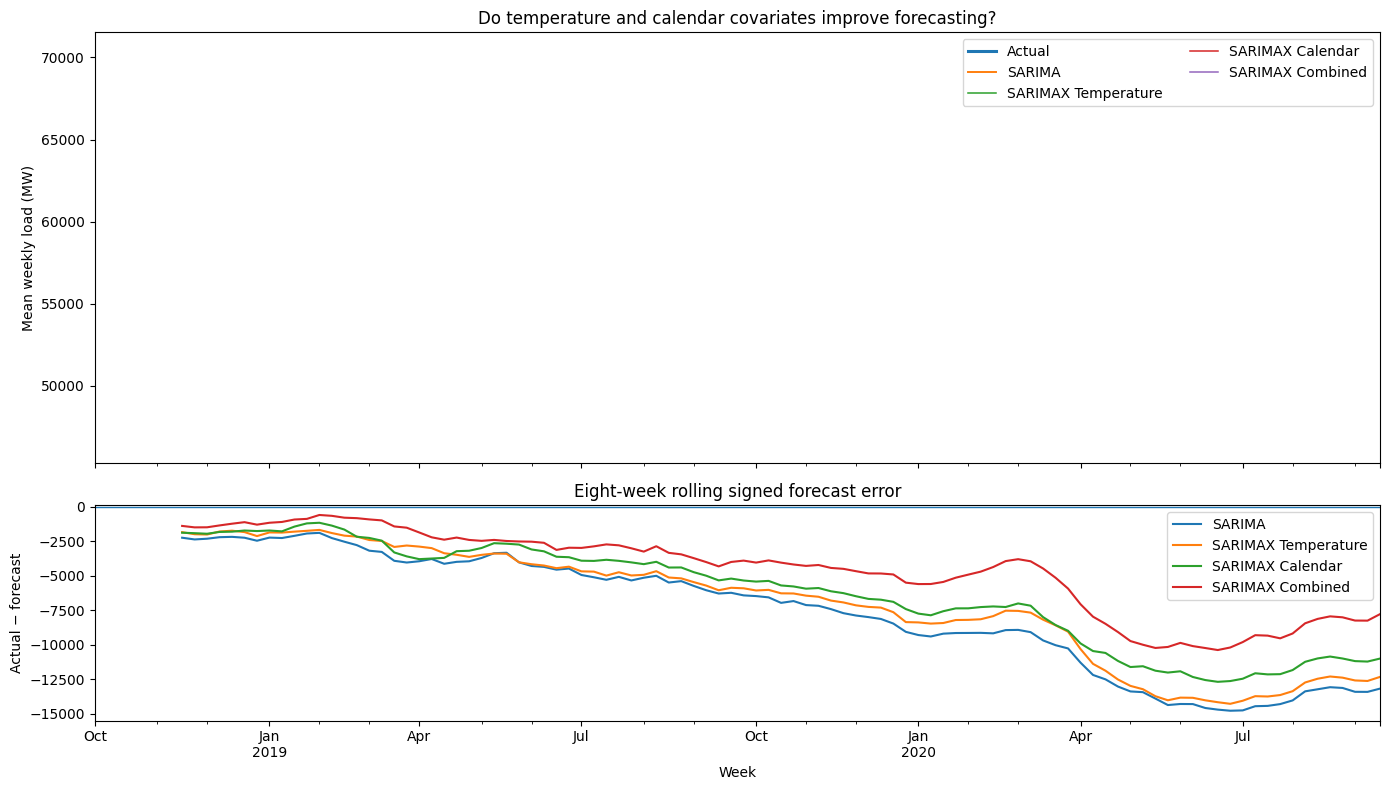

Important: SARIMAX models using observed test-period temperature are conditional forecasts.


In [9]:
# CELL 9 — SARIMAX covariate ablation

training_exogenous = (
    exogenous_weekly
    .loc[y_train.index]
)

testing_exogenous = (
    exogenous_weekly
    .loc[y_test.index]
)

sarimax_feature_sets = {
    "SARIMAX Temperature": [
        "temp_mean",
        "HDD18",
        "CDD22"
    ],

    "SARIMAX Calendar": [
        "holiday_days",
        "working_days",
        "christmas_new_year",
        "week_sin",
        "week_cos",
        "trend"
    ],

    "SARIMAX Combined": [
        "temp_mean",
        "HDD18",
        "CDD22",
        "holiday_days",
        "working_days",
        "christmas_new_year",
        "week_sin",
        "week_cos",
        "trend"
    ]
}

sarimax_metric_rows = []
sarimax_intervals = {}

for model_name, selected_columns in (
    sarimax_feature_sets.items()
):

    model = SARIMAX(
        y_train,
        exog=training_exogenous[
            selected_columns
        ],
        order=best_order,
        seasonal_order=best_seasonal_order,
        trend="n",
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(
        method="lbfgs",
        maxiter=160,
        disp=False
    )

    forecast_result = (
        result
        .get_forecast(
            steps=len(y_test),
            exog=testing_exogenous[
                selected_columns
            ]
        )
    )

    prediction = pd.Series(
        forecast_result
        .predicted_mean
        .to_numpy(),
        index=y_test.index,
        name=model_name
    )

    predictions[model_name] = prediction

    metric_row = evaluate_forecast(
        y_test,
        prediction,
        y_train
    )

    metric_row["Model"] = model_name
    metric_row["AIC"] = result.aic

    sarimax_metric_rows.append(
        metric_row
    )

    confidence_interval = (
        forecast_result
        .conf_int()
    )

    confidence_interval.index = (
        y_test.index
    )

    sarimax_intervals[
        model_name
    ] = confidence_interval


sarimax_metrics = (
    pd.DataFrame(
        sarimax_metric_rows
    )
    .set_index("Model")
    .sort_values("RMSE")
)

display(
    sarimax_metrics.round(3)
)

sarimax_metrics.to_csv(
    TABLE_DIR
    / "sarimax_ablation_metrics.csv"
)


# ---------------------------------------------------------
# FIGURE 12: Covariate ablation and rolling errors
# ---------------------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 8),
    sharex=True,
    gridspec_kw={
        "height_ratios": [2, 1]
    }
)

axes[0].plot(
    y_test,
    linewidth=2.2,
    label="Actual"
)

axes[0].plot(
    predictions["SARIMA"],
    linewidth=1.4,
    label="SARIMA"
)

for model_name in sarimax_feature_sets:

    axes[0].plot(
        predictions[model_name],
        linewidth=1.1,
        label=model_name
    )

axes[0].set_title(
    "Do temperature and calendar covariates improve forecasting?"
)

axes[0].set_ylabel(
    "Mean weekly load (MW)"
)

axes[0].legend(
    ncol=2
)

signed_errors = pd.concat({
    model_name: (
        y_test
        - predictions[model_name]
    )
    for model_name in [
        "SARIMA",
        *sarimax_feature_sets.keys()
    ]
}, axis=1)

signed_errors.rolling(
    window=8
).mean().plot(
    ax=axes[1]
)

axes[1].axhline(
    0,
    linewidth=1
)

axes[1].set_title(
    "Eight-week rolling signed forecast error"
)

axes[1].set_xlabel("Week")
axes[1].set_ylabel("Actual − forecast")

save_plot(
    "12_sarimax_covariate_ablation.png"
)

print(
    "Important: SARIMAX models using observed "
    "test-period temperature are conditional forecasts."
)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Gradient Boosting parameters:
{'subsample': 0.8, 'n_estimators': 300, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'max_depth': 3, 'learning_rate': 0.08}


,MAE,RMSE,sMAPE_percent,MASE
Gradient Boosting,2277.969,2951.827,4.223,1.686


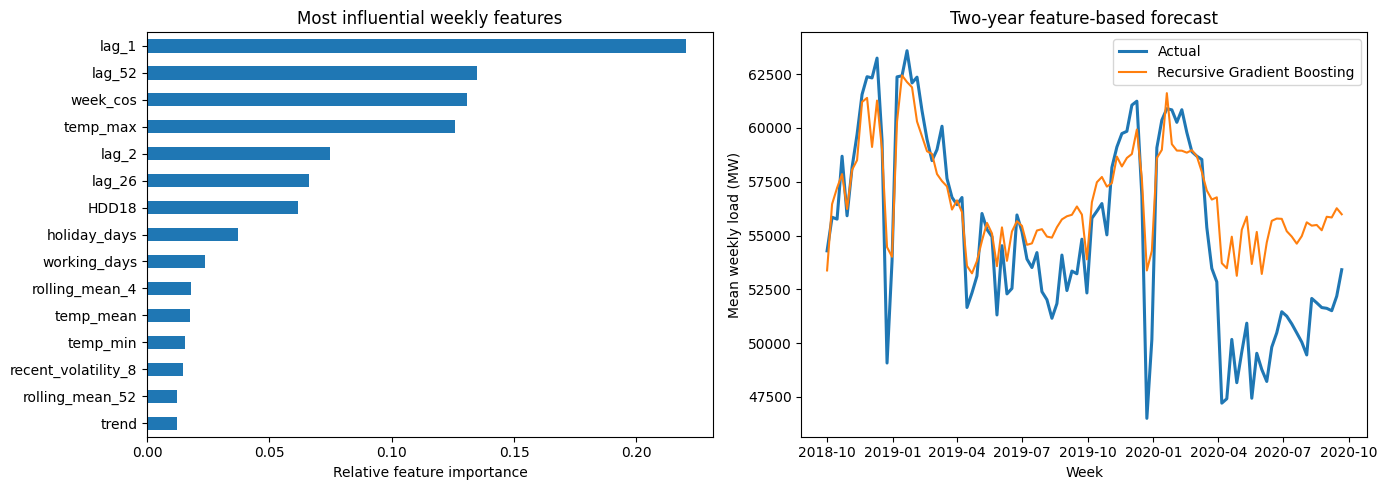

The Gradient Boosting forecast uses recursive load values. Temperature inputs remain conditional.


In [10]:
# CELL 10 — Leakage-safe Gradient Boosting model

def create_supervised_training_data(
    load_series,
    exogenous_frame
):
    """
    Build weekly training rows using only load values
    available before each target week.
    """

    rows = []

    for target_date in load_series.index:

        past_load = (
            load_series
            .loc[:target_date]
            .iloc[:-1]
        )

        if len(past_load) < 52:
            continue

        row = {
            "target": load_series.loc[target_date],

            "lag_1": past_load.iloc[-1],
            "lag_2": past_load.iloc[-2],
            "lag_4": past_load.iloc[-4],
            "lag_13": past_load.iloc[-13],
            "lag_26": past_load.iloc[-26],
            "lag_52": past_load.iloc[-52],

            "rolling_mean_4": (
                past_load
                .iloc[-4:]
                .mean()
            ),

            "rolling_mean_13": (
                past_load
                .iloc[-13:]
                .mean()
            ),

            "rolling_mean_52": (
                past_load
                .iloc[-52:]
                .mean()
            ),

            "recent_volatility_8": (
                past_load
                .iloc[-8:]
                .std()
            )
        }

        row.update(
            exogenous_frame
            .loc[target_date]
            .to_dict()
        )

        row["date"] = target_date

        rows.append(row)

    return (
        pd.DataFrame(rows)
        .set_index("date")
    )


gradient_training_data = (
    create_supervised_training_data(
        y_train,
        training_exogenous
    )
)

X_gradient = (
    gradient_training_data
    .drop(columns="target")
)

y_gradient = (
    gradient_training_data["target"]
)

gradient_parameter_space = {
    "n_estimators": [
        100,
        150,
        200,
        300
    ],
    "learning_rate": [
        0.02,
        0.03,
        0.05,
        0.08
    ],
    "max_depth": [
        2,
        3,
        4
    ],
    "min_samples_leaf": [
        3,
        5,
        8,
        12
    ],
    "subsample": [
        0.7,
        0.8,
        1.0
    ],
    "max_features": [
        None,
        "sqrt",
        0.8
    ]
}

time_series_cv = TimeSeriesSplit(
    n_splits=5
)

gradient_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),
    param_distributions=gradient_parameter_space,
    n_iter=24,
    scoring="neg_mean_absolute_error",
    cv=time_series_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

gradient_search.fit(
    X_gradient,
    y_gradient
)

print(
    "Best Gradient Boosting parameters:"
)

print(
    gradient_search.best_params_
)


# ---------------------------------------------------------
# Recursive two-year weekly forecast
# ---------------------------------------------------------

recursive_history = y_train.copy()
gradient_forecast_values = []

for forecast_date in y_test.index:

    load_history = recursive_history.copy()

    feature_row = {
        "lag_1": load_history.iloc[-1],
        "lag_2": load_history.iloc[-2],
        "lag_4": load_history.iloc[-4],
        "lag_13": load_history.iloc[-13],
        "lag_26": load_history.iloc[-26],
        "lag_52": load_history.iloc[-52],

        "rolling_mean_4": (
            load_history
            .iloc[-4:]
            .mean()
        ),

        "rolling_mean_13": (
            load_history
            .iloc[-13:]
            .mean()
        ),

        "rolling_mean_52": (
            load_history
            .iloc[-52:]
            .mean()
        ),

        "recent_volatility_8": (
            load_history
            .iloc[-8:]
            .std()
        )
    }

    feature_row.update(
        testing_exogenous
        .loc[forecast_date]
        .to_dict()
    )

    next_features = pd.DataFrame(
        [feature_row],
        index=[forecast_date]
    )

    # Enforce the same column order used during training.
    next_features = next_features[
        X_gradient.columns
    ]

    next_prediction = float(
        gradient_search
        .best_estimator_
        .predict(
            next_features
        )[0]
    )

    gradient_forecast_values.append(
        next_prediction
    )

    # The prediction becomes part of future history.
    recursive_history.loc[
        forecast_date
    ] = next_prediction


gradient_prediction = pd.Series(
    gradient_forecast_values,
    index=y_test.index,
    name="Gradient Boosting"
)

predictions[
    "Gradient Boosting"
] = gradient_prediction

gradient_metrics = evaluate_forecast(
    y_test,
    gradient_prediction,
    y_train
)

display(
    pd.DataFrame(
        [gradient_metrics],
        index=["Gradient Boosting"]
    ).round(3)
)


# ---------------------------------------------------------
# FIGURE 13: Feature importance and forecast
# ---------------------------------------------------------

feature_importance = pd.Series(
    gradient_search
    .best_estimator_
    .feature_importances_,
    index=X_gradient.columns
)

feature_importance = (
    feature_importance
    .sort_values()
    .tail(15)
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

feature_importance.plot(
    kind="barh",
    ax=axes[0],
    title="Most influential weekly features"
)

axes[0].set_xlabel(
    "Relative feature importance"
)

axes[1].plot(
    y_test,
    linewidth=2.2,
    label="Actual"
)

axes[1].plot(
    gradient_prediction,
    label="Recursive Gradient Boosting"
)

axes[1].set_title(
    "Two-year feature-based forecast"
)

axes[1].set_xlabel("Week")

axes[1].set_ylabel(
    "Mean weekly load (MW)"
)

axes[1].legend()

save_plot(
    "13_gradient_boosting.png"
)

print(
    "The Gradient Boosting forecast uses recursive "
    "load values. Temperature inputs remain conditional."
)

Hourly LSTM period: 2015-01-01 00:00:00+00:00 to 2020-09-27 23:00:00+00:00
Validation begins: 2018-09-03 00:00:00+00:00
Test begins: 2018-10-01 00:00:00+00:00
Tuning training shape: (4002, 168, 1)
Validation shape: (672, 168, 1)

Training: Memory_Lite_LSTM
Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 229ms/step - loss: 1.0338 - val_loss: 0.8546 - learning_rate: 0.0010
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - loss: 0.9472 - val_loss: 0.7754 - learning_rate: 0.0010
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.8644 - val_loss: 0.6939 - learning_rate: 0.0010
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 0.7639 - val_loss: 0.5940 - learning_rate: 0.0010
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.6279 - val_loss: 0.4576 - learning_rate: 0.0010

Training: Compact_Stacked_LSTM
Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 288ms/step - loss: 0.9588 - val_loss: 0.8013 - learning_rate: 8.0000e-04
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 200ms/step - los

,name,units,dropout,learning_rate,best_epoch,validation_scaled_MAE
0,Memory_Lite_LSTM,[16],0.1,0.0010,5,0.457573
1,Compact_Stacked_LSTM,"[24, 12]",0.1,0.0008,5,0.545642


Selected model: Memory_Lite_LSTM
Final epochs: 5
Final training shape: (8172, 168, 1)
Final test shape: (17472, 168, 1)
Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - loss: 0.6395
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - loss: 0.5496
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.4435
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.3396
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.2899
Forecast protocol: rolling one-hour-ahead LSTM using the latest observed 168 hours.
The model is a compact secondary comparison for Assignment 10.

Hourly evaluation:


,MAE,RMSE,sMAPE_percent,Peak_10pct_MAE
Hourly Seasonal Naive,2489.796,4294.073,4.606,2734.902
Compact Hourly LSTM,2400.692,3121.999,4.502,2909.428



Weekly aggregated evaluation:


,MAE,RMSE,sMAPE_percent,MASE
LSTM Aggregated,646.685,804.583,1.15,0.479


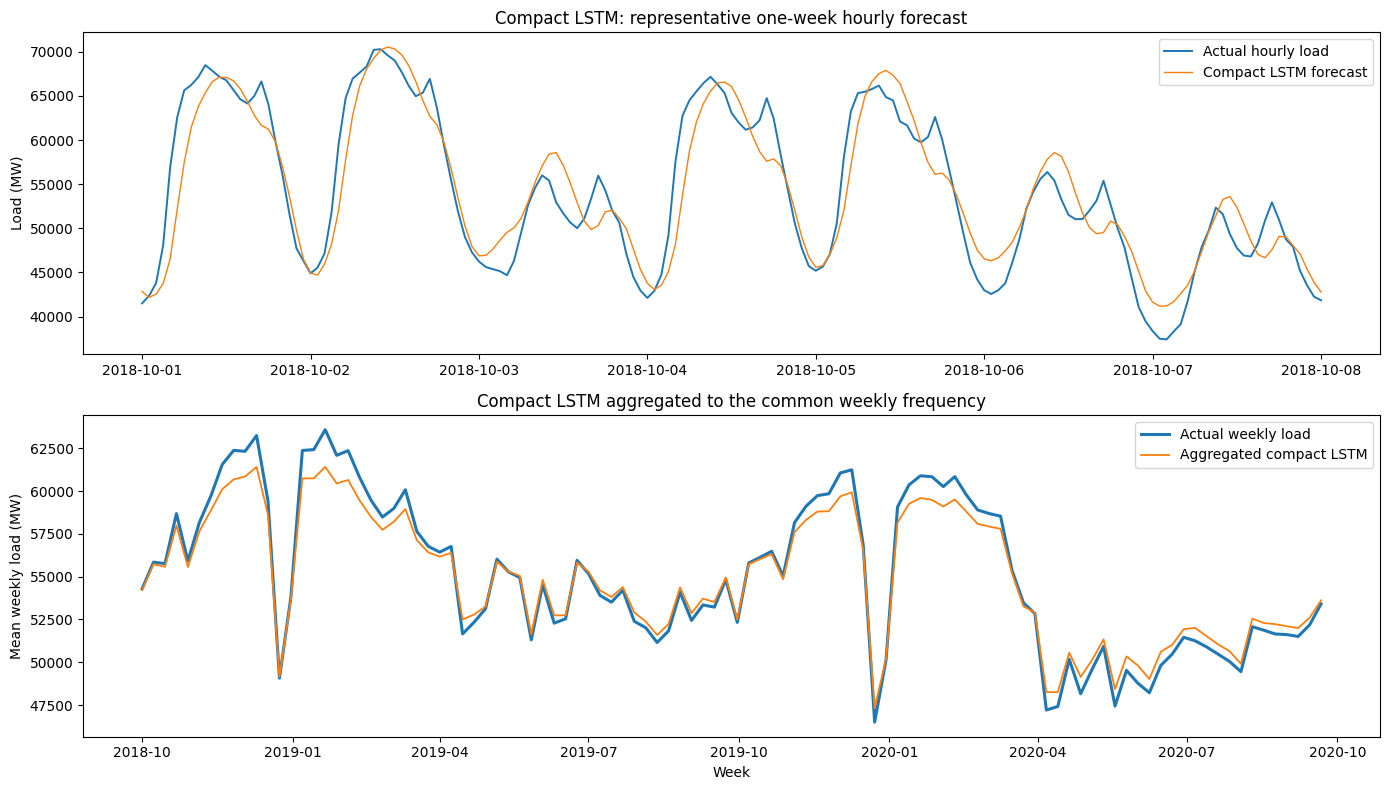

Figure saved to: outputs/figures/compact_lstm_secondary_comparison.png


5528

In [16]:
# ============================================================

#
# Runtime reductions:
# - Two lightweight architectures
# - Maximum five epochs
# - Four validation weeks
# - Vectorised sequence generation
# - Sampled chronological training sequences
# - Larger training and prediction batches
#
# Required previous variables:
# hourly, y_train, y_test, predictions
# ============================================================

import gc
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)


# ------------------------------------------------------------
# TENSORFLOW IMPORT
# ------------------------------------------------------------

try:
    import tensorflow as tf

    from tensorflow.keras import Sequential

    from tensorflow.keras.layers import (
        Input,
        LSTM,
        Dense,
        Dropout
    )

    from tensorflow.keras.callbacks import (
        EarlyStopping,
        ReduceLROnPlateau
    )

except ImportError as error:

    raise ImportError(
        "TensorFlow is required. Run this cell in "
        "Google Colab or install TensorFlow."
    ) from error


# ------------------------------------------------------------
# FALLBACK SETTINGS AND OUTPUT FOLDERS
# ------------------------------------------------------------

RANDOM_STATE = globals().get(
    "RANDOM_STATE",
    42
)

tf.keras.utils.set_random_seed(
    RANDOM_STATE
)

TABLE_DIR = Path(
    globals().get(
        "TABLE_DIR",
        "outputs/tables"
    )
)

FIGURE_DIR = Path(
    globals().get(
        "FIGURE_DIR",
        "outputs/figures"
    )
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Infer the weekly frequency when it was not defined earlier.
WEEK_FREQ = globals().get(
    "WEEK_FREQ",
    pd.infer_freq(
        y_test.index
    ) or "W-SUN"
)

if "predictions" not in globals():
    predictions = {}


def save_figure(filename):
    """Save and display the current figure."""

    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ------------------------------------------------------------
# FALLBACK METRIC FUNCTIONS
# ------------------------------------------------------------

if "smape" not in globals():

    def smape(actual, predicted):
        """Symmetric mean absolute percentage error."""

        actual = np.asarray(
            actual,
            dtype=float
        )

        predicted = np.asarray(
            predicted,
            dtype=float
        )

        denominator = (
            np.abs(actual)
            + np.abs(predicted)
        )

        error = np.where(
            denominator == 0,
            0,
            2
            * np.abs(
                actual - predicted
            )
            / denominator
        )

        return 100 * np.mean(error)


if "evaluate_forecast" not in globals():

    def evaluate_forecast(
        actual,
        predicted,
        training_series
    ):
        """Evaluate one weekly forecast."""

        actual = pd.Series(
            actual
        ).astype(float)

        predicted = pd.Series(
            np.asarray(
                predicted,
                dtype=float
            ),
            index=actual.index
        )

        training_values = np.asarray(
            training_series,
            dtype=float
        )

        if len(training_values) > 52:

            mase_scale = np.mean(
                np.abs(
                    training_values[52:]
                    - training_values[:-52]
                )
            )

            mase_value = (
                mean_absolute_error(
                    actual,
                    predicted
                )
                / mase_scale
            )

        else:
            mase_value = np.nan

        return {
            "MAE": mean_absolute_error(
                actual,
                predicted
            ),

            "RMSE": np.sqrt(
                mean_squared_error(
                    actual,
                    predicted
                )
            ),

            "sMAPE_percent": smape(
                actual,
                predicted
            ),

            "MASE": mase_value,

            "Bias": np.mean(
                actual.to_numpy()
                - predicted.to_numpy()
            )
        }


# ------------------------------------------------------------
# NORMALISE THE HOURLY INPUT
# ------------------------------------------------------------

if isinstance(
    hourly,
    pd.DataFrame
):

    if hourly.shape[1] != 1:
        raise ValueError(
            "The hourly DataFrame must contain one load column."
        )

    hourly_series = (
        hourly
        .iloc[:, 0]
        .astype(float)
        .copy()
    )

else:
    hourly_series = (
        pd.Series(hourly)
        .astype(float)
        .copy()
    )

hourly_series = (
    hourly_series
    .sort_index()
)

if hourly_series.isna().any():

    hourly_series = (
        hourly_series
        .interpolate(
            method="time",
            limit_direction="both"
        )
        .ffill()
        .bfill()
    )


# ------------------------------------------------------------
# COMPACT LSTM SETTINGS
# ------------------------------------------------------------

# One full week of hourly demand history.
LOOKBACK = 168

# Short recent validation period.
VALIDATION_WEEKS = 4

# Use only selected chronological sequences.
TUNING_STRIDE = 8
FINAL_TRAINING_STRIDE = 4

MAXIMUM_EPOCHS = 5
BATCH_SIZE = 256


# Preserve the original notebook's test alignment.
hourly_test_start = (
    y_test.index.min()
)

hourly_test_end = (
    y_test.index.max()
    + pd.Timedelta(weeks=1)
)

hourly_validation_start = (
    hourly_test_start
    - pd.Timedelta(
        weeks=VALIDATION_WEEKS
    )
)

hourly_for_lstm = (
    hourly_series
    .loc[
        :
        hourly_test_end
        - pd.Timedelta(hours=1)
    ]
    .copy()
)

print(
    "Hourly LSTM period:",
    hourly_for_lstm.index.min(),
    "to",
    hourly_for_lstm.index.max()
)

print(
    "Validation begins:",
    hourly_validation_start
)

print(
    "Test begins:",
    hourly_test_start
)


# ------------------------------------------------------------
# FAST VECTORISED SEQUENCE CREATION
# ------------------------------------------------------------

def make_sequences_fast(
    scaled_values,
    timestamps,
    lookback
):
    """
    Create overlapping 168-hour sequences without
    repeatedly appending values in a Python loop.
    """

    values = np.asarray(
        scaled_values,
        dtype=np.float32
    ).reshape(-1)

    windows = (
        np.lib.stride_tricks
        .sliding_window_view(
            values,
            lookback + 1
        )
    )

    X_values = (
        windows[:, :-1]
        [:, :, np.newaxis]
    )

    y_values = windows[:, -1]

    target_times = pd.DatetimeIndex(
        timestamps[lookback:]
    )

    return (
        X_values,
        y_values,
        target_times
    )


# ------------------------------------------------------------
# BUILD A SMALL LSTM
# ------------------------------------------------------------

def build_compact_lstm(
    configuration
):
    """Build a one-layer or small stacked LSTM."""

    model = Sequential()

    model.add(
        Input(
            shape=(
                LOOKBACK,
                1
            )
        )
    )

    for layer_number, units in enumerate(
        configuration["units"]
    ):

        return_sequences = (
            layer_number
            < len(
                configuration["units"]
            ) - 1
        )

        model.add(
            LSTM(
                units,
                return_sequences=return_sequences
            )
        )

        model.add(
            Dropout(
                configuration["dropout"]
            )
        )

    model.add(
        Dense(1)
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=configuration[
                "learning_rate"
            ]
        ),
        loss="mae"
    )

    return model


# ------------------------------------------------------------
# PREPARE TUNING DATA WITHOUT LEAKAGE
# ------------------------------------------------------------

tuning_scaler = StandardScaler()

tuning_scaler.fit(
    hourly_for_lstm.loc[
        hourly_for_lstm.index
        < hourly_validation_start
    ]
    .to_numpy()
    .reshape(-1, 1)
)

scaled_tuning = (
    tuning_scaler
    .transform(
        hourly_for_lstm
        .to_numpy()
        .reshape(-1, 1)
    )
    .astype(np.float32)
)

(
    X_tuning_all,
    y_tuning_all,
    tuning_target_index
) = make_sequences_fast(
    scaled_tuning,
    hourly_for_lstm.index,
    LOOKBACK
)

training_mask = (
    tuning_target_index
    < hourly_validation_start
)

validation_mask = (
    (
        tuning_target_index
        >= hourly_validation_start
    )
    &
    (
        tuning_target_index
        < hourly_test_start
    )
)

X_tune_train = np.ascontiguousarray(
    X_tuning_all[
        training_mask
    ][::TUNING_STRIDE]
)

y_tune_train = np.ascontiguousarray(
    y_tuning_all[
        training_mask
    ][::TUNING_STRIDE]
)

X_tune_validation = np.ascontiguousarray(
    X_tuning_all[
        validation_mask
    ]
)

y_tune_validation = np.ascontiguousarray(
    y_tuning_all[
        validation_mask
    ]
)

print(
    "Tuning training shape:",
    X_tune_train.shape
)

print(
    "Validation shape:",
    X_tune_validation.shape
)


# ------------------------------------------------------------
# TWO SMALL ARCHITECTURES
# ------------------------------------------------------------

lstm_configurations = [
    {
        "name": "Memory_Lite_LSTM",
        "units": [16],
        "dropout": 0.10,
        "learning_rate": 0.001
    },

    {
        "name": "Compact_Stacked_LSTM",
        "units": [24, 12],
        "dropout": 0.10,
        "learning_rate": 0.0008
    }
]


# ------------------------------------------------------------
# SHORT ARCHITECTURE COMPARISON
# ------------------------------------------------------------

tuning_records = []

for configuration in lstm_configurations:

    print(
        "\nTraining:",
        configuration["name"]
    )

    tf.keras.backend.clear_session()
    gc.collect()

    candidate_model = build_compact_lstm(
        configuration
    )

    history = candidate_model.fit(
        X_tune_train,
        y_tune_train,

        validation_data=(
            X_tune_validation,
            y_tune_validation
        ),

        epochs=MAXIMUM_EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=False,

        callbacks=[
            EarlyStopping(
                monitor="val_loss",
                patience=1,
                restore_best_weights=True
            ),

            ReduceLROnPlateau(
                monitor="val_loss",
                patience=1,
                factor=0.5,
                min_lr=1e-5
            )
        ],

        verbose=1
    )

    best_epoch = int(
        np.argmin(
            history.history[
                "val_loss"
            ]
        ) + 1
    )

    best_validation_mae = float(
        np.min(
            history.history[
                "val_loss"
            ]
        )
    )

    tuning_records.append({
        **configuration,

        "best_epoch": best_epoch,

        "validation_scaled_MAE": (
            best_validation_mae
        )
    })

    del candidate_model
    gc.collect()


lstm_tuning_table = (
    pd.DataFrame(
        tuning_records
    )
    .sort_values(
        "validation_scaled_MAE"
    )
    .reset_index(drop=True)
)

display(
    lstm_tuning_table
)

lstm_tuning_table.to_csv(
    TABLE_DIR / "lstm_tuning_results.csv",
    index=False
)

best_lstm_configuration = (
    lstm_tuning_table
    .iloc[0]
    .to_dict()
)

final_epochs = max(
    2,
    min(
        int(
            best_lstm_configuration[
                "best_epoch"
            ]
        ),
        MAXIMUM_EPOCHS
    )
)

print(
    "Selected model:",
    best_lstm_configuration[
        "name"
    ]
)

print(
    "Final epochs:",
    final_epochs
)


# ------------------------------------------------------------
# PREPARE FINAL TRAINING AND TEST DATA
# ------------------------------------------------------------

final_scaler = StandardScaler()

final_scaler.fit(
    hourly_for_lstm.loc[
        hourly_for_lstm.index
        < hourly_test_start
    ]
    .to_numpy()
    .reshape(-1, 1)
)

scaled_final = (
    final_scaler
    .transform(
        hourly_for_lstm
        .to_numpy()
        .reshape(-1, 1)
    )
    .astype(np.float32)
)

(
    X_final_all,
    y_final_all,
    final_target_index
) = make_sequences_fast(
    scaled_final,
    hourly_for_lstm.index,
    LOOKBACK
)

final_training_mask = (
    final_target_index
    < hourly_test_start
)

final_test_mask = (
    (
        final_target_index
        >= hourly_test_start
    )
    &
    (
        final_target_index
        < hourly_test_end
    )
)

X_final_train = np.ascontiguousarray(
    X_final_all[
        final_training_mask
    ][::FINAL_TRAINING_STRIDE]
)

y_final_train = np.ascontiguousarray(
    y_final_all[
        final_training_mask
    ][::FINAL_TRAINING_STRIDE]
)

X_final_test = np.ascontiguousarray(
    X_final_all[
        final_test_mask
    ]
)

y_final_test = np.ascontiguousarray(
    y_final_all[
        final_test_mask
    ]
)

lstm_test_index = final_target_index[
    final_test_mask
]

print(
    "Final training shape:",
    X_final_train.shape
)

print(
    "Final test shape:",
    X_final_test.shape
)


# ------------------------------------------------------------
# RESTORE THE SELECTED CONFIGURATION
# ------------------------------------------------------------

selected_units = (
    best_lstm_configuration[
        "units"
    ]
)

if isinstance(
    selected_units,
    str
):

    selected_units = ast.literal_eval(
        selected_units
    )

selected_configuration = {
    "units": selected_units,

    "dropout": float(
        best_lstm_configuration[
            "dropout"
        ]
    ),

    "learning_rate": float(
        best_lstm_configuration[
            "learning_rate"
        ]
    )
}


# ------------------------------------------------------------
# TRAIN THE FINAL COMPACT LSTM
# ------------------------------------------------------------

tf.keras.backend.clear_session()
gc.collect()

final_lstm = build_compact_lstm(
    selected_configuration
)

final_lstm.fit(
    X_final_train,
    y_final_train,
    epochs=final_epochs,
    batch_size=BATCH_SIZE,
    shuffle=False,
    verbose=1
)


# ------------------------------------------------------------
# GENERATE HOURLY PREDICTIONS
# ------------------------------------------------------------

scaled_hourly_prediction = (
    final_lstm
    .predict(
        X_final_test,
        batch_size=1024,
        verbose=0
    )
    .reshape(-1, 1)
)

hourly_prediction_values = (
    final_scaler
    .inverse_transform(
        scaled_hourly_prediction
    )
    .ravel()
)

hourly_actual_values = (
    final_scaler
    .inverse_transform(
        y_final_test.reshape(-1, 1)
    )
    .ravel()
)

lstm_hourly_prediction = pd.Series(
    hourly_prediction_values,
    index=lstm_test_index,
    name="LSTM_hourly"
)

lstm_hourly_actual = pd.Series(
    hourly_actual_values,
    index=lstm_test_index,
    name="Actual_hourly"
)


# ------------------------------------------------------------
# HOURLY SEASONAL-NAIVE BASELINE
# ------------------------------------------------------------

hourly_seasonal_naive = (
    hourly_series
    .shift(168)
    .reindex(
        lstm_test_index
    )
)


# ------------------------------------------------------------
# HOURLY METRICS
# ------------------------------------------------------------

hourly_lstm_metrics = pd.DataFrame({
    "Hourly Seasonal Naive": {
        "MAE": mean_absolute_error(
            lstm_hourly_actual,
            hourly_seasonal_naive
        ),

        "RMSE": np.sqrt(
            mean_squared_error(
                lstm_hourly_actual,
                hourly_seasonal_naive
            )
        ),

        "sMAPE_percent": smape(
            lstm_hourly_actual,
            hourly_seasonal_naive
        )
    },

    "Compact Hourly LSTM": {
        "MAE": mean_absolute_error(
            lstm_hourly_actual,
            lstm_hourly_prediction
        ),

        "RMSE": np.sqrt(
            mean_squared_error(
                lstm_hourly_actual,
                lstm_hourly_prediction
            )
        ),

        "sMAPE_percent": smape(
            lstm_hourly_actual,
            lstm_hourly_prediction
        )
    }
}).T


# High-demand hours remain useful operational evidence.
peak_threshold = (
    lstm_hourly_actual
    .quantile(0.90)
)

peak_mask = (
    lstm_hourly_actual
    >= peak_threshold
)

hourly_lstm_metrics[
    "Peak_10pct_MAE"
] = [
    mean_absolute_error(
        lstm_hourly_actual[
            peak_mask
        ],
        hourly_seasonal_naive[
            peak_mask
        ]
    ),

    mean_absolute_error(
        lstm_hourly_actual[
            peak_mask
        ],
        lstm_hourly_prediction[
            peak_mask
        ]
    )
]


# ------------------------------------------------------------
# AGGREGATE TO WEEKLY FREQUENCY
# ------------------------------------------------------------
# Two alignment conventions are tested. The one matching the
# existing y_test index most completely is retained.

weekly_left_aligned = (
    lstm_hourly_prediction
    .resample(
        WEEK_FREQ,
        label="left",
        closed="left"
    )
    .mean()
    .reindex(
        y_test.index
    )
)

weekly_default_aligned = (
    lstm_hourly_prediction
    .resample(
        WEEK_FREQ
    )
    .mean()
    .reindex(
        y_test.index
    )
)

if (
    weekly_left_aligned
    .isna()
    .sum()
    <=
    weekly_default_aligned
    .isna()
    .sum()
):

    lstm_weekly_prediction = (
        weekly_left_aligned
    )

else:
    lstm_weekly_prediction = (
        weekly_default_aligned
    )


if lstm_weekly_prediction.isna().any():

    missing_weeks = int(
        lstm_weekly_prediction
        .isna()
        .sum()
    )

    raise ValueError(
        f"The LSTM produced {missing_weeks} missing "
        "weekly predictions. Check the weekly index."
    )


predictions[
    "LSTM Aggregated"
] = lstm_weekly_prediction

lstm_weekly_metrics = evaluate_forecast(
    y_test,
    lstm_weekly_prediction,
    y_train
)


# ------------------------------------------------------------
# DISPLAY AND EXPORT RESULTS
# ------------------------------------------------------------

print(
    "Forecast protocol: rolling one-hour-ahead LSTM "
    "using the latest observed 168 hours."
)

print(
    "The model is a compact secondary comparison "
    "for Assignment 10."
)

print("\nHourly evaluation:")

display(
    hourly_lstm_metrics.round(3)
)

print("\nWeekly aggregated evaluation:")

display(
    pd.DataFrame(
        [lstm_weekly_metrics],
        index=["LSTM Aggregated"]
    ).round(3)
)

hourly_lstm_metrics.to_csv(
    TABLE_DIR / "hourly_lstm_metrics.csv"
)


# ------------------------------------------------------------
# ONE COMPACT SUPPORTING FIGURE
# ------------------------------------------------------------

sample_end = (
    lstm_hourly_prediction.index.min()
    + pd.Timedelta(days=7)
)

sample_actual = (
    lstm_hourly_actual
    .loc[:sample_end]
)

sample_prediction = (
    lstm_hourly_prediction
    .loc[:sample_end]
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 8)
)

axes[0].plot(
    sample_actual.index,
    sample_actual,
    linewidth=1.4,
    label="Actual hourly load"
)

axes[0].plot(
    sample_prediction.index,
    sample_prediction,
    linewidth=1.0,
    label="Compact LSTM forecast"
)

axes[0].set_title(
    "Compact LSTM: representative one-week hourly forecast"
)

axes[0].set_ylabel(
    "Load (MW)"
)

axes[0].legend()


axes[1].plot(
    y_test.index,
    y_test,
    linewidth=2.2,
    label="Actual weekly load"
)

axes[1].plot(
    lstm_weekly_prediction.index,
    lstm_weekly_prediction,
    linewidth=1.3,
    label="Aggregated compact LSTM"
)

axes[1].set_title(
    "Compact LSTM aggregated to the common weekly frequency"
)

axes[1].set_xlabel(
    "Week"
)

axes[1].set_ylabel(
    "Mean weekly load (MW)"
)

axes[1].legend()

save_figure(
    "compact_lstm_secondary_comparison.png"
)

print(
    "Figure saved to:",
    FIGURE_DIR
    / "compact_lstm_secondary_comparison.png"
)


# ------------------------------------------------------------
# RELEASE LARGE TEMPORARY ARRAYS
# ------------------------------------------------------------

del (
    X_tuning_all,
    y_tuning_all,
    X_final_all,
    y_final_all,
    X_tune_train,
    y_tune_train,
    X_tune_validation,
    y_tune_validation,
    X_final_train,
    y_final_train,
    X_final_test,
    y_final_test
)

gc.collect()

,MAE,RMSE,sMAPE_percent,MASE,Forecast_type,RMSE_improvement_vs_seasonal_naive_percent
Model,,,,,,
LSTM Aggregated,646.685,804.583,1.150,0.479,"Rolling one-hour-ahead, aggregated weekly",73.075
Gradient Boosting,2277.969,2951.827,4.223,1.686,Conditional recursive weekly forecast,1.219
Seasonal Naive,2288.489,2988.248,4.207,1.694,Unconditional,0.000
Mean,3789.845,4402.059,6.874,2.805,Unconditional,-47.312
Drift,3850.776,4466.494,6.982,2.850,Unconditional,-49.469
Naive,3858.148,4475.767,6.995,2.856,Unconditional,-49.779
SARIMAX Combined,4642.899,5647.337,8.240,3.436,Conditional: observed future temperature,-88.985
SARIMAX Calendar,6327.929,7420.263,10.970,4.684,Operational covariates known in advance,-148.315
SARIMAX Temperature,7019.564,8301.019,12.091,5.196,Conditional: observed future temperature,-177.789


Best SARIMAX version: SARIMAX Combined


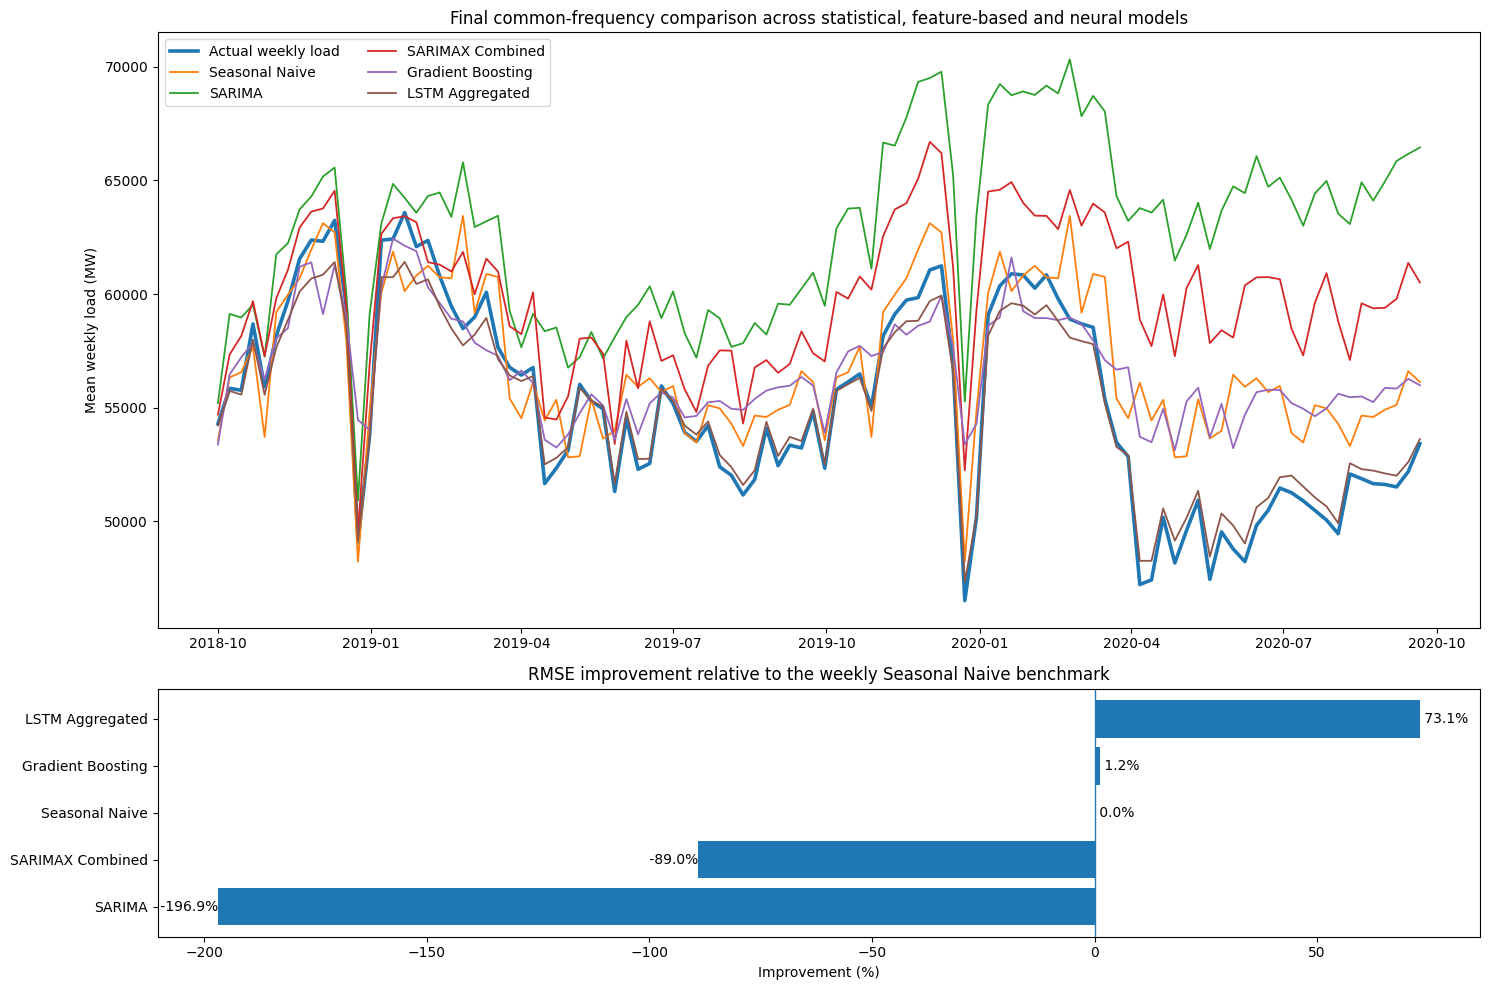

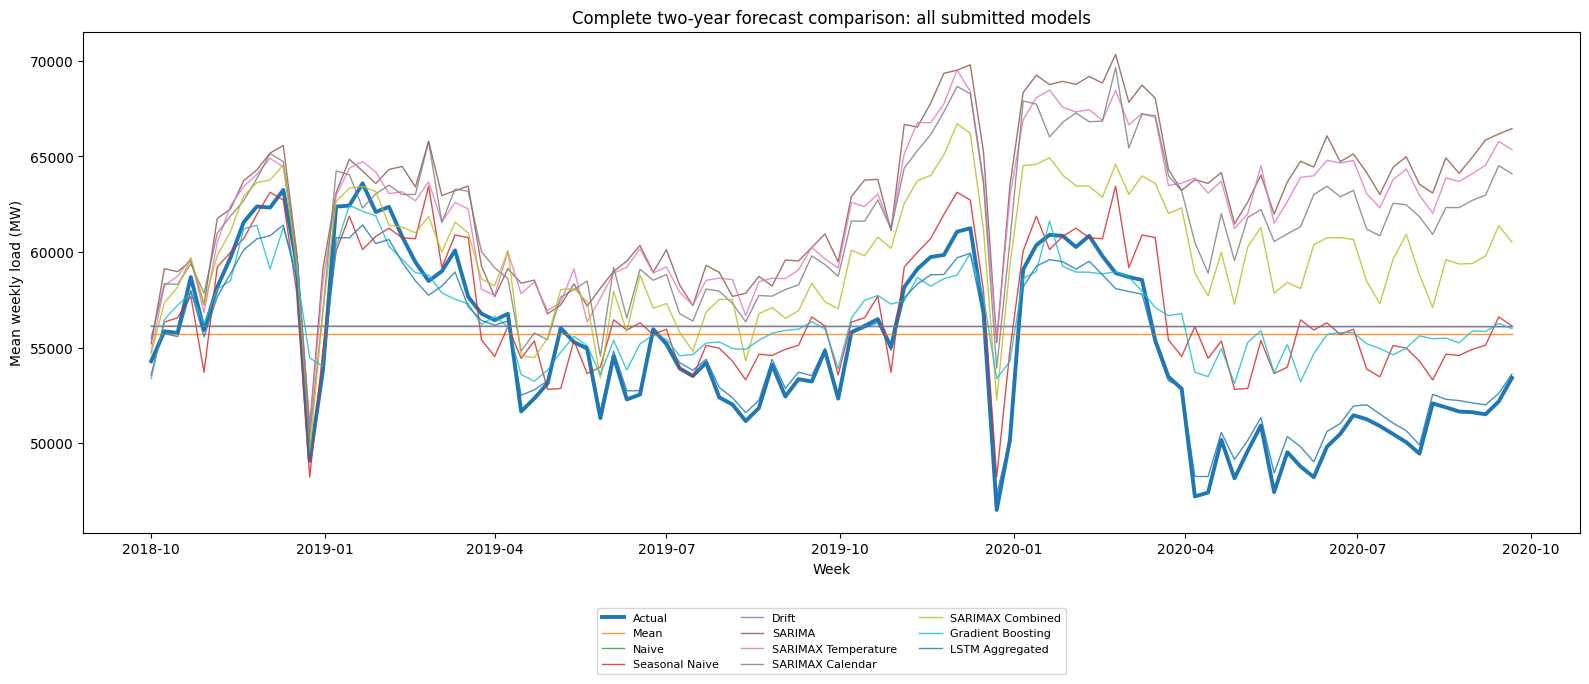

Lowest weekly RMSE: LSTM Aggregated
Interpret the strongest model together with forecast type, confidence intervals, covariate availability, interpretability and maintenance requirements.
All report-ready outputs are saved under: /content/outputs


In [17]:
# ============================================================
# CELL 12: FINAL COMMON-FREQUENCY MODEL COMPARISON
# ============================================================
# This cell:
# 1. Recalculates every weekly model metric using the same
#    104-week test period.
# 2. Compares every model with Seasonal Naive.
# 3. Records whether each forecast is conditional,
#    unconditional or operational.
# 4. Selects the strongest SARIMAX version for the main figure.
# 5. Creates a clean report figure.
# 6. Creates an additional figure containing every forecast.
# 7. Exports final metrics and predictions for the report
#    and GitHub repository.
#
# This is the original Cell 12 and uses variables produced
# by the previous old cells.
# ============================================================


# ------------------------------------------------------------
# RECALCULATE ALL WEEKLY MODEL METRICS
# ------------------------------------------------------------

weekly_metric_rows = []

# This mapping prevents conditional forecasts from being
# incorrectly described as fully operational forecasts.
forecast_type_map = {
    "Mean": "Unconditional",

    "Naive": "Unconditional",

    "Seasonal Naive": "Unconditional",

    "Drift": "Unconditional",

    "SARIMA": "Unconditional",

    "SARIMAX Temperature": (
        "Conditional: observed future temperature"
    ),

    "SARIMAX Calendar": (
        "Operational covariates known in advance"
    ),

    "SARIMAX Combined": (
        "Conditional: observed future temperature"
    ),

    "Gradient Boosting": (
        "Conditional recursive weekly forecast"
    ),

    "LSTM Aggregated": (
        "Rolling one-hour-ahead, aggregated weekly"
    )
}


for model_name, model_prediction in (
    predictions.items()
):

    # Ensure every model is evaluated against exactly the
    # same weekly test dates.
    aligned_prediction = (
        model_prediction
        .reindex(
            y_test.index
        )
    )

    # A model with incomplete predictions cannot be compared
    # fairly in the final common-frequency table.
    if aligned_prediction.isna().any():

        print(
            f"Warning: {model_name} contains missing weekly "
            "predictions and will be omitted from the final "
            "common-frequency table."
        )

        continue

    model_metrics = evaluate_forecast(
        y_test,
        aligned_prediction,
        y_train
    )

    model_metrics[
        "Model"
    ] = model_name

    model_metrics[
        "Forecast_type"
    ] = forecast_type_map.get(
        model_name,
        "Not specified"
    )

    weekly_metric_rows.append(
        model_metrics
    )


# Create the final model-comparison table.
final_metrics = (
    pd.DataFrame(
        weekly_metric_rows
    )
    .set_index(
        "Model"
    )
)


# ------------------------------------------------------------
# CALCULATE IMPROVEMENT OVER SEASONAL NAIVE
# ------------------------------------------------------------

seasonal_naive_rmse = final_metrics.loc[
    "Seasonal Naive",
    "RMSE"
]

final_metrics[
    "RMSE_improvement_vs_seasonal_naive_percent"
] = (
    100
    * (
        seasonal_naive_rmse
        - final_metrics[
            "RMSE"
        ]
    )
    / seasonal_naive_rmse
)

# Lowest RMSE appears first.
final_metrics = (
    final_metrics
    .sort_values(
        "RMSE"
    )
)

display(
    final_metrics.round(3)
)


# ------------------------------------------------------------
# SELECT THE STRONGEST SARIMAX VERSION
# ------------------------------------------------------------

# Identify SARIMAX models that successfully reached the
# final comparison table.
available_sarimax = [
    model_name

    for model_name in sarimax_feature_sets

    if model_name in final_metrics.index
]

# Select the SARIMAX version with the lowest weekly RMSE.
best_sarimax_name = (
    final_metrics
    .loc[
        available_sarimax,
        "RMSE"
    ]
    .idxmin()
)

print(
    "Best SARIMAX version:",
    best_sarimax_name
)


# The main report figure uses the most important models
# rather than overcrowding the visual with every benchmark.
final_plot_models = [
    "Seasonal Naive",
    "SARIMA",
    best_sarimax_name,
    "Gradient Boosting",
    "LSTM Aggregated"
]


# ------------------------------------------------------------
# FIGURE 15: MAIN COMMON-FREQUENCY COMPARISON
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(15, 10),
    gridspec_kw={
        "height_ratios": [
            2.4,
            1
        ]
    }
)


# Plot the actual weekly test observations.
axes[0].plot(
    y_test.index,
    y_test,
    linewidth=2.6,
    label="Actual weekly load"
)

# Plot the selected forecasting approaches.
for model_name in final_plot_models:

    axes[0].plot(
        y_test.index,

        predictions[
            model_name
        ].reindex(
            y_test.index
        ),

        linewidth=1.3,
        label=model_name
    )

axes[0].set_title(
    "Final common-frequency comparison across statistical, "
    "feature-based and neural models"
)

axes[0].set_ylabel(
    "Mean weekly load (MW)"
)

axes[0].legend(
    ncol=2
)


# ------------------------------------------------------------
# SHOW RMSE IMPROVEMENT OVER SEASONAL NAIVE
# ------------------------------------------------------------

improvement = (
    final_metrics
    .loc[
        final_plot_models,
        "RMSE_improvement_vs_seasonal_naive_percent"
    ]
    .sort_values()
)

bars = axes[1].barh(
    improvement.index,
    improvement.values
)

axes[1].axvline(
    0,
    linewidth=1
)

axes[1].set_title(
    "RMSE improvement relative to the weekly "
    "Seasonal Naive benchmark"
)

axes[1].set_xlabel(
    "Improvement (%)"
)


# Write each improvement percentage beside its bar.
for bar, value in zip(
    bars,
    improvement.values
):

    axes[1].text(
        value,

        bar.get_y()
        + bar.get_height() / 2,

        f" {value:.1f}%",

        va="center",

        ha=(
            "left"
            if value >= 0
            else "right"
        )
    )

save_figure(
    "15_final_all_model_comparison.png"
)


# ------------------------------------------------------------
# FIGURE 16: COMPLETE FORECAST COMPARISON
# ------------------------------------------------------------
# This second figure contains all submitted forecasts and can
# be retained in the repository as evidence that every model
# was completed. The cleaner Figure 15 is better for the report.

fig, axis = plt.subplots(
    figsize=(16, 7)
)

axis.plot(
    y_test.index,
    y_test,
    linewidth=2.8,
    label="Actual"
)

for model_name, model_prediction in (
    predictions.items()
):

    # Plot only models with complete evaluation results.
    if model_name in final_metrics.index:

        axis.plot(
            y_test.index,

            model_prediction.reindex(
                y_test.index
            ),

            linewidth=1.0,
            alpha=0.82,
            label=model_name
        )

axis.set_title(
    "Complete two-year forecast comparison: "
    "all submitted models"
)

axis.set_xlabel(
    "Week"
)

axis.set_ylabel(
    "Mean weekly load (MW)"
)

axis.legend(
    ncol=3,
    fontsize=8,
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        -0.14
    )
)

save_figure(
    "16_complete_all_forecasts.png"
)


# ------------------------------------------------------------
# EXPORT FINAL TABLES AND PREDICTIONS
# ------------------------------------------------------------

# Store actual values and all forecasts in one table.
prediction_table = pd.DataFrame({
    "Actual": y_test,

    **{
        model_name: model_prediction.reindex(
            y_test.index
        )

        for model_name, model_prediction
        in predictions.items()
    }
})


# Final weekly metrics.
final_metrics.to_csv(
    TABLE_DIR / "final_weekly_model_metrics.csv"
)

# Actual weekly demand and every model forecast.
prediction_table.to_csv(
    TABLE_DIR / "final_weekly_predictions.csv"
)

# Separate hourly LSTM evaluation.
hourly_lstm_metrics.to_csv(
    TABLE_DIR / "hourly_lstm_metrics.csv"
)


# ------------------------------------------------------------
# PRINT FINAL SUMMARY
# ------------------------------------------------------------

best_weekly_model = (
    final_metrics.index[0]
)

print(
    "Lowest weekly RMSE:",
    best_weekly_model
)

print(
    "Interpret the strongest model together with forecast "
    "type, confidence intervals, covariate availability, "
    "interpretability and maintenance requirements."
)

print(
    "All report-ready outputs are saved under:",
    OUTPUT_DIR.resolve()
)